# Ground truth of the data

The following notebook analysed the ground truth of the eyetracking data. 
There is a seperate notebook just analysing pd_on vs. pd_off 

## Initializing

In [ ]:
from pathlib import Path
import os

cwd = Path.cwd()
#or set manual: 
#cwd = '.../ScanDy'

for parent in [cwd] + list(cwd.parents):
    if (parent / "data").exists():
        os.chdir(parent)
        break

print(Path.cwd())


/mnt/raid/data/anina/ScanDy/notebooks_and_scripts/groundtruth_analysis
/mnt/raid/data/anina/ScanDy


In [2]:
import importlib
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from matplotlib.legend_handler import HandlerTuple

from scipy import stats
from scipy import stats as sp_stats
from scipy.stats import ttest_rel, ttest_ind, wilcoxon, mannwhitneyu, ttest_1samp, spearmanr

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf

from scikit_posthocs import posthoc_dunn

# --- scandy_pfc ---
import scandy_pfc.models.ObjectModel as objectmodel_module
import scandy_pfc.models.model as base_model
import scandy_pfc.utils.dataclass as dataclass_module


In [3]:
# color settings
dircl = ['xkcd:maroon', sns.color_palette("Dark2")[1], sns.color_palette("Dark2")[5], sns.color_palette("Dark2")[6] ]
mcl = ['xkcd:blue', 'xkcd:red']


In [4]:
# Reload this if anything changes in the module - no need for kernel reload :)
importlib.reload(dataclass_module)
Dataset = dataclass_module.Dataset
importlib.reload(base_model)
importlib.reload(objectmodel_module)
ObjectModel = objectmodel_module.ObjectModel

In [5]:
dataframe_files = {
    "young": 'parkinson_data/df_img_fovs_psycsci.csv',
    "old":  'parkinson_data/df_img_fovs_controls.csv',
    "pd_on": 'parkinson_data/df_img_fovs_parkinson_with.csv',
    "pd_off": 'parkinson_data/df_img_fovs_parkinson_without.csv'

}

# Resized for faster processing
folder_path = "PictureExample/PictureExample_Resized/picture"
files = [os.path.splitext(f)[0] for f in os.listdir(folder_path) 
         if os.path.isfile(os.path.join(folder_path, f)) and f.endswith(".png")]


In [6]:
animated_imglist = ["crowBall", "fingerTapping", "statues", "work2", "pedestrian", 
                     "fish", "chessBoard", "youtube", "axolotl", "lizard", "coffeeOnSofa", 
                     "reindeers", "openDoorOutside", "throw", "shoebill", "chimpanzee", 
                     "bird", "mail", "plank", "shoot", "heron", "monitorLizard", "bench", 
                     "work", "bigAnimalBackground", "conversation", "watering", "robot2", 
                     "giraffe", "crow", "bikeUnlocking", "monkey2", "fly", "trash", 
                     "selfie", "catcafe", "yoga", "elevatorWrongSide", "lake", "construction"]

non_animated_imglist = ["blueBoiler", "watercooler", "birdFalling", "sealion", 
                        "sparkling2", "ventilator", "kettle", "waterbottle", "clock", 
                        "penDrawing", "gondolaUp", "laundry", "receipt", "bottleString", 
                        "stapler", "elevatorEmpty", "waterHose", "carStart", "billboard", 
                        "teabagOut", "snip", "disinfectant", "mokaPot", "trinkvogel2", 
                        "ballBalance", "rippingPaper", "phone", "toytrainHouses", "candle", 
                        "bed", "robot", "espresso", "trafficLight2", "skiLift", "dino", 
                        "toytrain", "openDoorInside", "trafficLight", "whiteBoard", "toaster"]

The following initializaton of Vidcom is used in whole notebook. Currently set to full imagelist and the corresponding train/testset. Can be changed to every possible subset. 

In [7]:
#full imagelist
imglist = sorted(files)
random.seed(12345)
trainlist = sorted(random.sample(imglist, 64)) #80% of total 80 images
testlist = sorted([vidname for vidname in imglist if vidname not in trainlist])

VidCom = {}

for key, gt_foveation_df in dataframe_files.items():
    dva = 47.7 if key == "young" else 40.45
    datadict = {
        "PATH": "PictureExample/PictureExample_Resized/",
        'FPS': 30,
        'PX_TO_DVA': ((dva * 0.8) / 1920)*4,
        'FRAMES_ALL_VIDS': 150,
        'VID_EXTENSION' : 'png',
        'gt_foveation_df': gt_foveation_df,
        'dataformat': 'picture', #video
        'NAME_COL': 'scene',
        'trainset': trainlist,
        'testset': testlist,
        'used_videos': imglist
    }
    ds = Dataset(datadict)
    VidCom[key] = ds


Video column is set to: scene
Video column is set to: scene
Video column is set to: scene
Video column is set to: scene


# Analyzisng ground truth of the data

## Foveation Duration and Saccade Amplitude

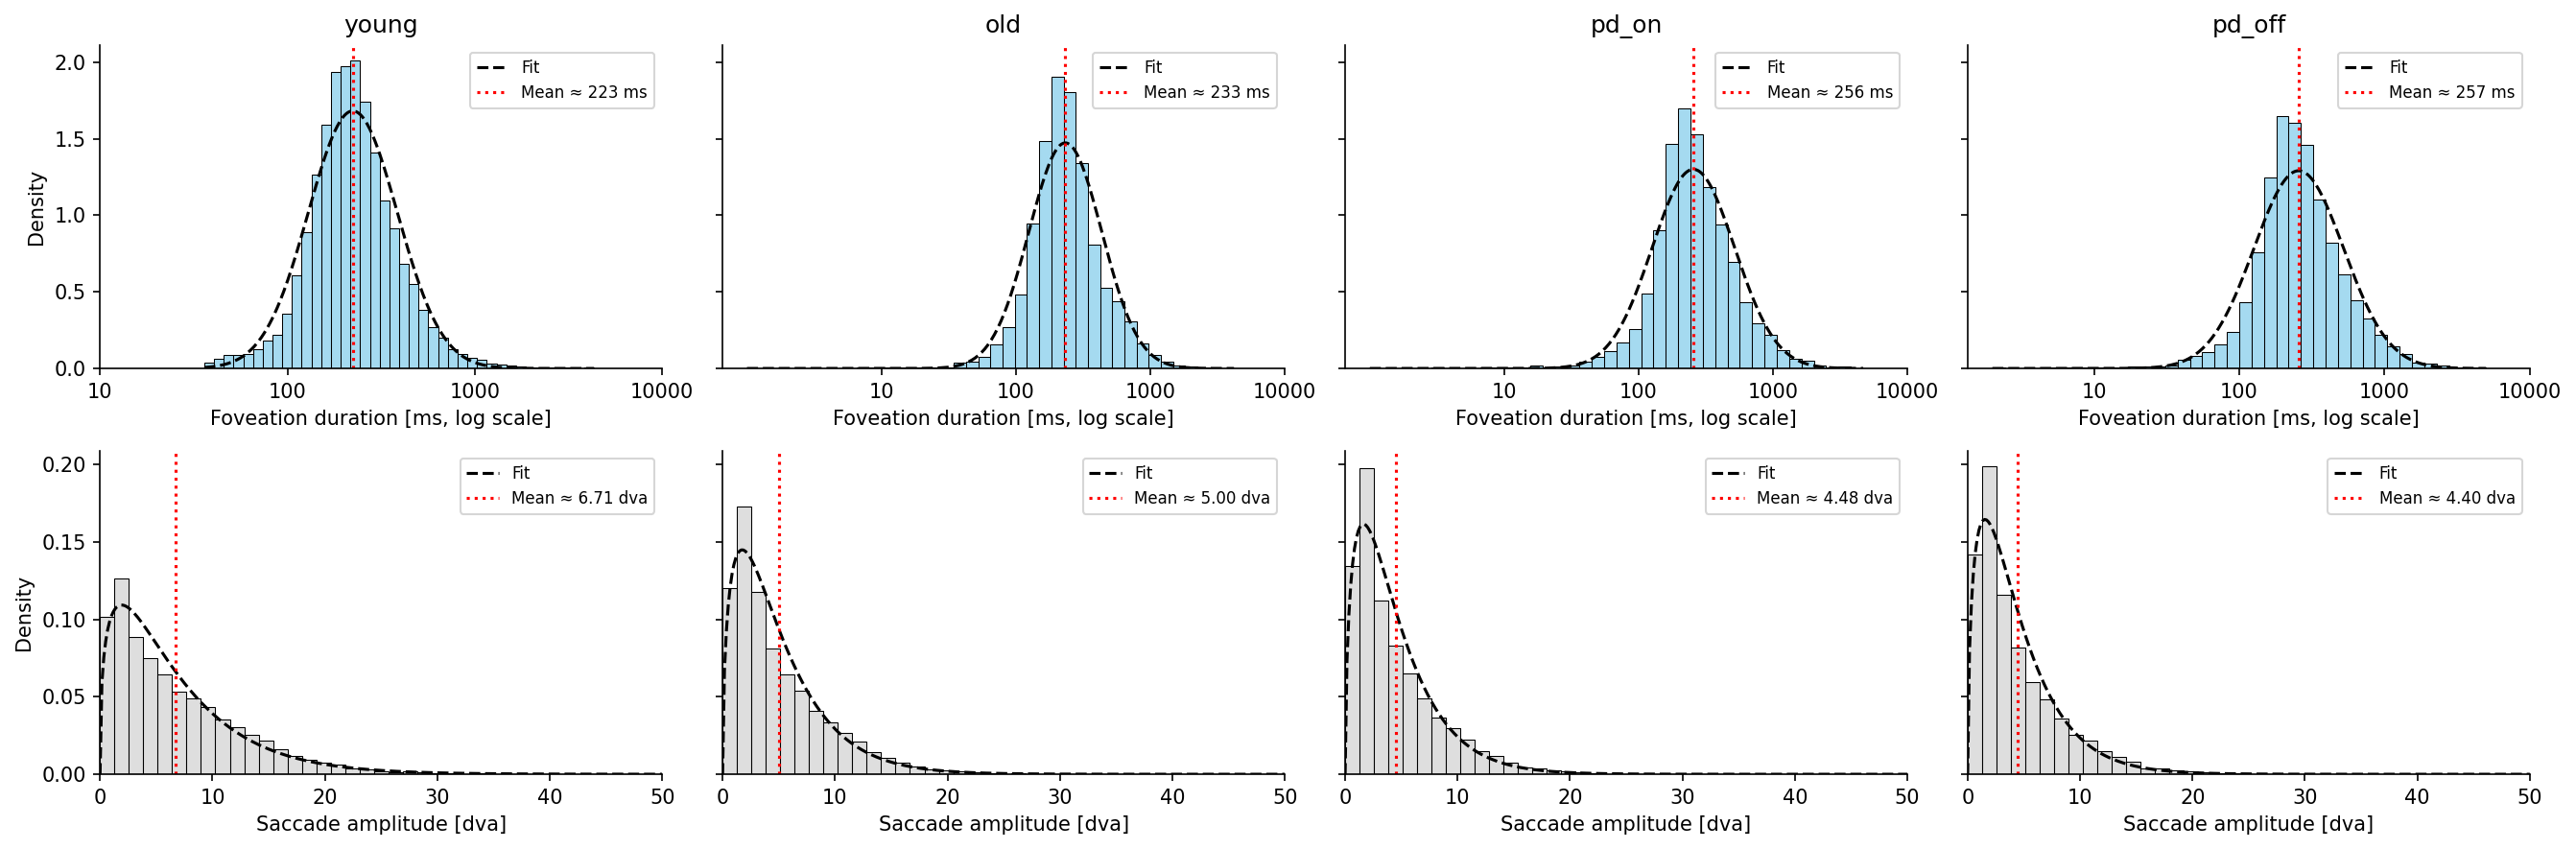

young dataset:
  Foveation duration fit (log10 space): (2.3488210608713076, 0.2372939551007589)
  Saccade amplitude fit: (1.4001012737974579, 0, 4.792045313836195)
old dataset:
  Foveation duration fit (log10 space): (2.368056175353407, 0.2708848016477109)
  Saccade amplitude fit: (1.5361960711353309, 0, 3.2549468901244167)
pd_on dataset:
  Foveation duration fit (log10 space): (2.4081584360859436, 0.30689308002179827)
  Saccade amplitude fit: (1.5708057045429835, 0, 2.851920033607762)
pd_off dataset:
  Foveation duration fit (log10 space): (2.4096079989187085, 0.3090558294185897)
  Saccade amplitude fit: (1.5388545000000908, 0, 2.8614870827386185)

===== Mixed-effects model: Duration =====
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        log_mean_dur
No. Observations:         144            Method:                    REML        
No. Groups:               56             Scale:                     0.0037     

In [8]:
stats_rows = []
conditions = [True, False]          # animated / not animated
condition_labels = ["Animate", "Not Animate"]

for key in VidCom.keys():
    df = VidCom[key].gt_foveation_df.copy()

    # --- same cleaning as in plots ---
    df["sac_amp_dva"] = pd.to_numeric(df["sac_amp_dva"], errors="coerce")
    df = df.dropna(subset=["duration_ms", "sac_amp_dva"])
    df = df[(df["duration_ms"] > 0) & (df["sac_amp_dva"] > 0.5)]

    for cond, label in zip(conditions, condition_labels):
        df_c = df[df["animate"] == cond]

        subj_stats = (
            df_c
            .groupby("subj_id")
            .agg(
                mean_dur=("duration_ms", "mean"),
                mean_amp=("sac_amp_dva", "mean"),
                n_fix=("duration_ms", "size"),
            )
            .reset_index()
        )

        subj_stats["group"] = key
        subj_stats["condition"] = label
        stats_rows.append(subj_stats)

stats_df = pd.concat(stats_rows, ignore_index=True)
stats_df["log_mean_dur"] = np.log(stats_df["mean_dur"])


fig, axs = plt.subplots(2, len(VidCom.keys()), dpi=150, figsize=(18, 6),
                        sharey='row')  

for col, key in enumerate(VidCom.keys()):
    data_set = VidCom[key]
    
    # Clean data
    gt_amp = data_set.gt_foveation_df["sac_amp_dva"].dropna().values
    gt_amp = gt_amp[gt_amp > 0.5]
    gt_dur = data_set.gt_foveation_df["duration_ms"].dropna().values
    gt_dur = gt_dur[np.isfinite(gt_dur) & (gt_dur > 0)]
    
    # Fits
    dur_log = np.log10(gt_dur)
    dur_mu, dur_sigma = stats.norm.fit(dur_log)
    amp_shape, amp_loc, amp_scale = stats.gamma.fit(gt_amp, floc=0)
    
    # PDF x-ranges
    dur_x = np.linspace(dur_log.min(), dur_log.max(), 300)
    amp_x = np.linspace(0, 50, 300)

    # --- Duration plot (log10) ---
    sns.histplot(dur_log, bins=40, ax=axs[0, col], stat="density", color="skyblue")
    axs[0, col].plot(dur_x, stats.norm.pdf(dur_x, dur_mu, dur_sigma), 'k--', label="Fit")

    mean_dur = 10**dur_mu  # in ms
    axs[0, col].axvline(dur_mu, color='red', linestyle=':', label=f"Mean ≈ {mean_dur:.0f} ms")

    axs[0, col].set_xticks([1, 2, 3, 4])
    axs[0, col].set_xticklabels(["10", "100", "1000", "10000"])
    axs[0, col].set_xlabel("Foveation duration [ms, log scale]")
    axs[0, col].set_title(key)
    axs[0, col].legend(fontsize=8)

    # --- Amplitude plot ---
    sns.histplot(gt_amp, bins=np.linspace(0, 50, 40), stat="density", ax=axs[1, col], color="lightgray")
    axs[1, col].plot(amp_x, stats.gamma.pdf(amp_x, amp_shape, loc=0, scale=amp_scale), 'k--', label="Fit")

    mean_amp = amp_shape * amp_scale  # Gamma mean
    axs[1, col].axvline(mean_amp, color='red', linestyle=':', label=f"Mean ≈ {mean_amp:.2f} dva")

    axs[1, col].set_xlim(0, 50)
    axs[1, col].set_xlabel("Saccade amplitude [dva]")
    axs[1, col].legend(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()


for key in VidCom.keys():
    data_set = VidCom[key]
    gt_amp_dva = data_set.gt_foveation_df["sac_amp_dva"].dropna().values
    gt_amp_dva = gt_amp_dva[gt_amp_dva > 0.5]
    gt_dur_ms = data_set.gt_foveation_df["duration_ms"].dropna().values

    # Needed as NAN in dataset
    gt_dur_ms_clean = gt_dur_ms[np.isfinite(gt_dur_ms) & (gt_dur_ms > 0)]
    ampfit = stats.gamma.fit(gt_amp_dva, floc=0)
    durfit = stats.norm.fit(np.log10(gt_dur_ms_clean))
    print(f"{key} dataset:")
    print("  Foveation duration fit (log10 space):", durfit)
    print("  Saccade amplitude fit:", ampfit)
    

stats_df["group"] = stats_df["group"].astype("category")
stats_df["condition"] = stats_df["condition"].astype("category")

stats_df["group"] = stats_df["group"].cat.reorder_categories(
    ["old", "young", "pd_on", "pd_off"], ordered=False
)
stats_df["condition"] = stats_df["condition"].cat.reorder_categories(
    ["Not Animate", "Animate"], ordered=False
)

print("\n===== Mixed-effects model: Duration =====")
m_dur = smf.mixedlm(
    "log_mean_dur ~ group * condition",
    stats_df,
    groups=stats_df["subj_id"]
).fit()

print(m_dur.summary())

print("\n===== Mixed-effects model: Amplitude =====")
m_amp = smf.mixedlm(
    "mean_amp ~ group * condition",
    stats_df,
    groups=stats_df["subj_id"]
).fit()

print(m_amp.summary())


#### Seperated by Imagecondition


Dataset: young, Condition: Animate
  Duration: n=11998, mean=271.9 ms, std=216.6 ms
    Fitted log-normal: mu=2.359, sigma=0.243, mean ≈ 228.6 ms
  Amplitude: n=10820, mean=6.66 dva, std=5.63 dva
    Fitted gamma: shape=1.387, scale=4.800, mean ≈ 6.66 dva

Dataset: young, Condition: Not Animate
  Duration: n=12593, mean=253.9 ms, std=178.0 ms
    Fitted log-normal: mu=2.339, sigma=0.231, mean ≈ 218.3 ms
  Amplitude: n=11435, mean=6.76 dva, std=5.67 dva
    Fitted gamma: shape=1.413, scale=4.784, mean ≈ 6.76 dva

Dataset: old, Condition: Animate
  Duration: n=10522, mean=286.3 ms, std=226.9 ms
    Fitted log-normal: mu=2.370, sigma=0.271, mean ≈ 234.6 ms
  Amplitude: n=9424, mean=4.95 dva, std=4.22 dva
    Fitted gamma: shape=1.521, scale=3.254, mean ≈ 4.95 dva

Dataset: old, Condition: Not Animate
  Duration: n=10279, mean=281.5 ms, std=209.2 ms
    Fitted log-normal: mu=2.366, sigma=0.271, mean ≈ 232.2 ms
  Amplitude: n=9272, mean=5.05 dva, std=4.28 dva
    Fitted gamma: shape=1.552,

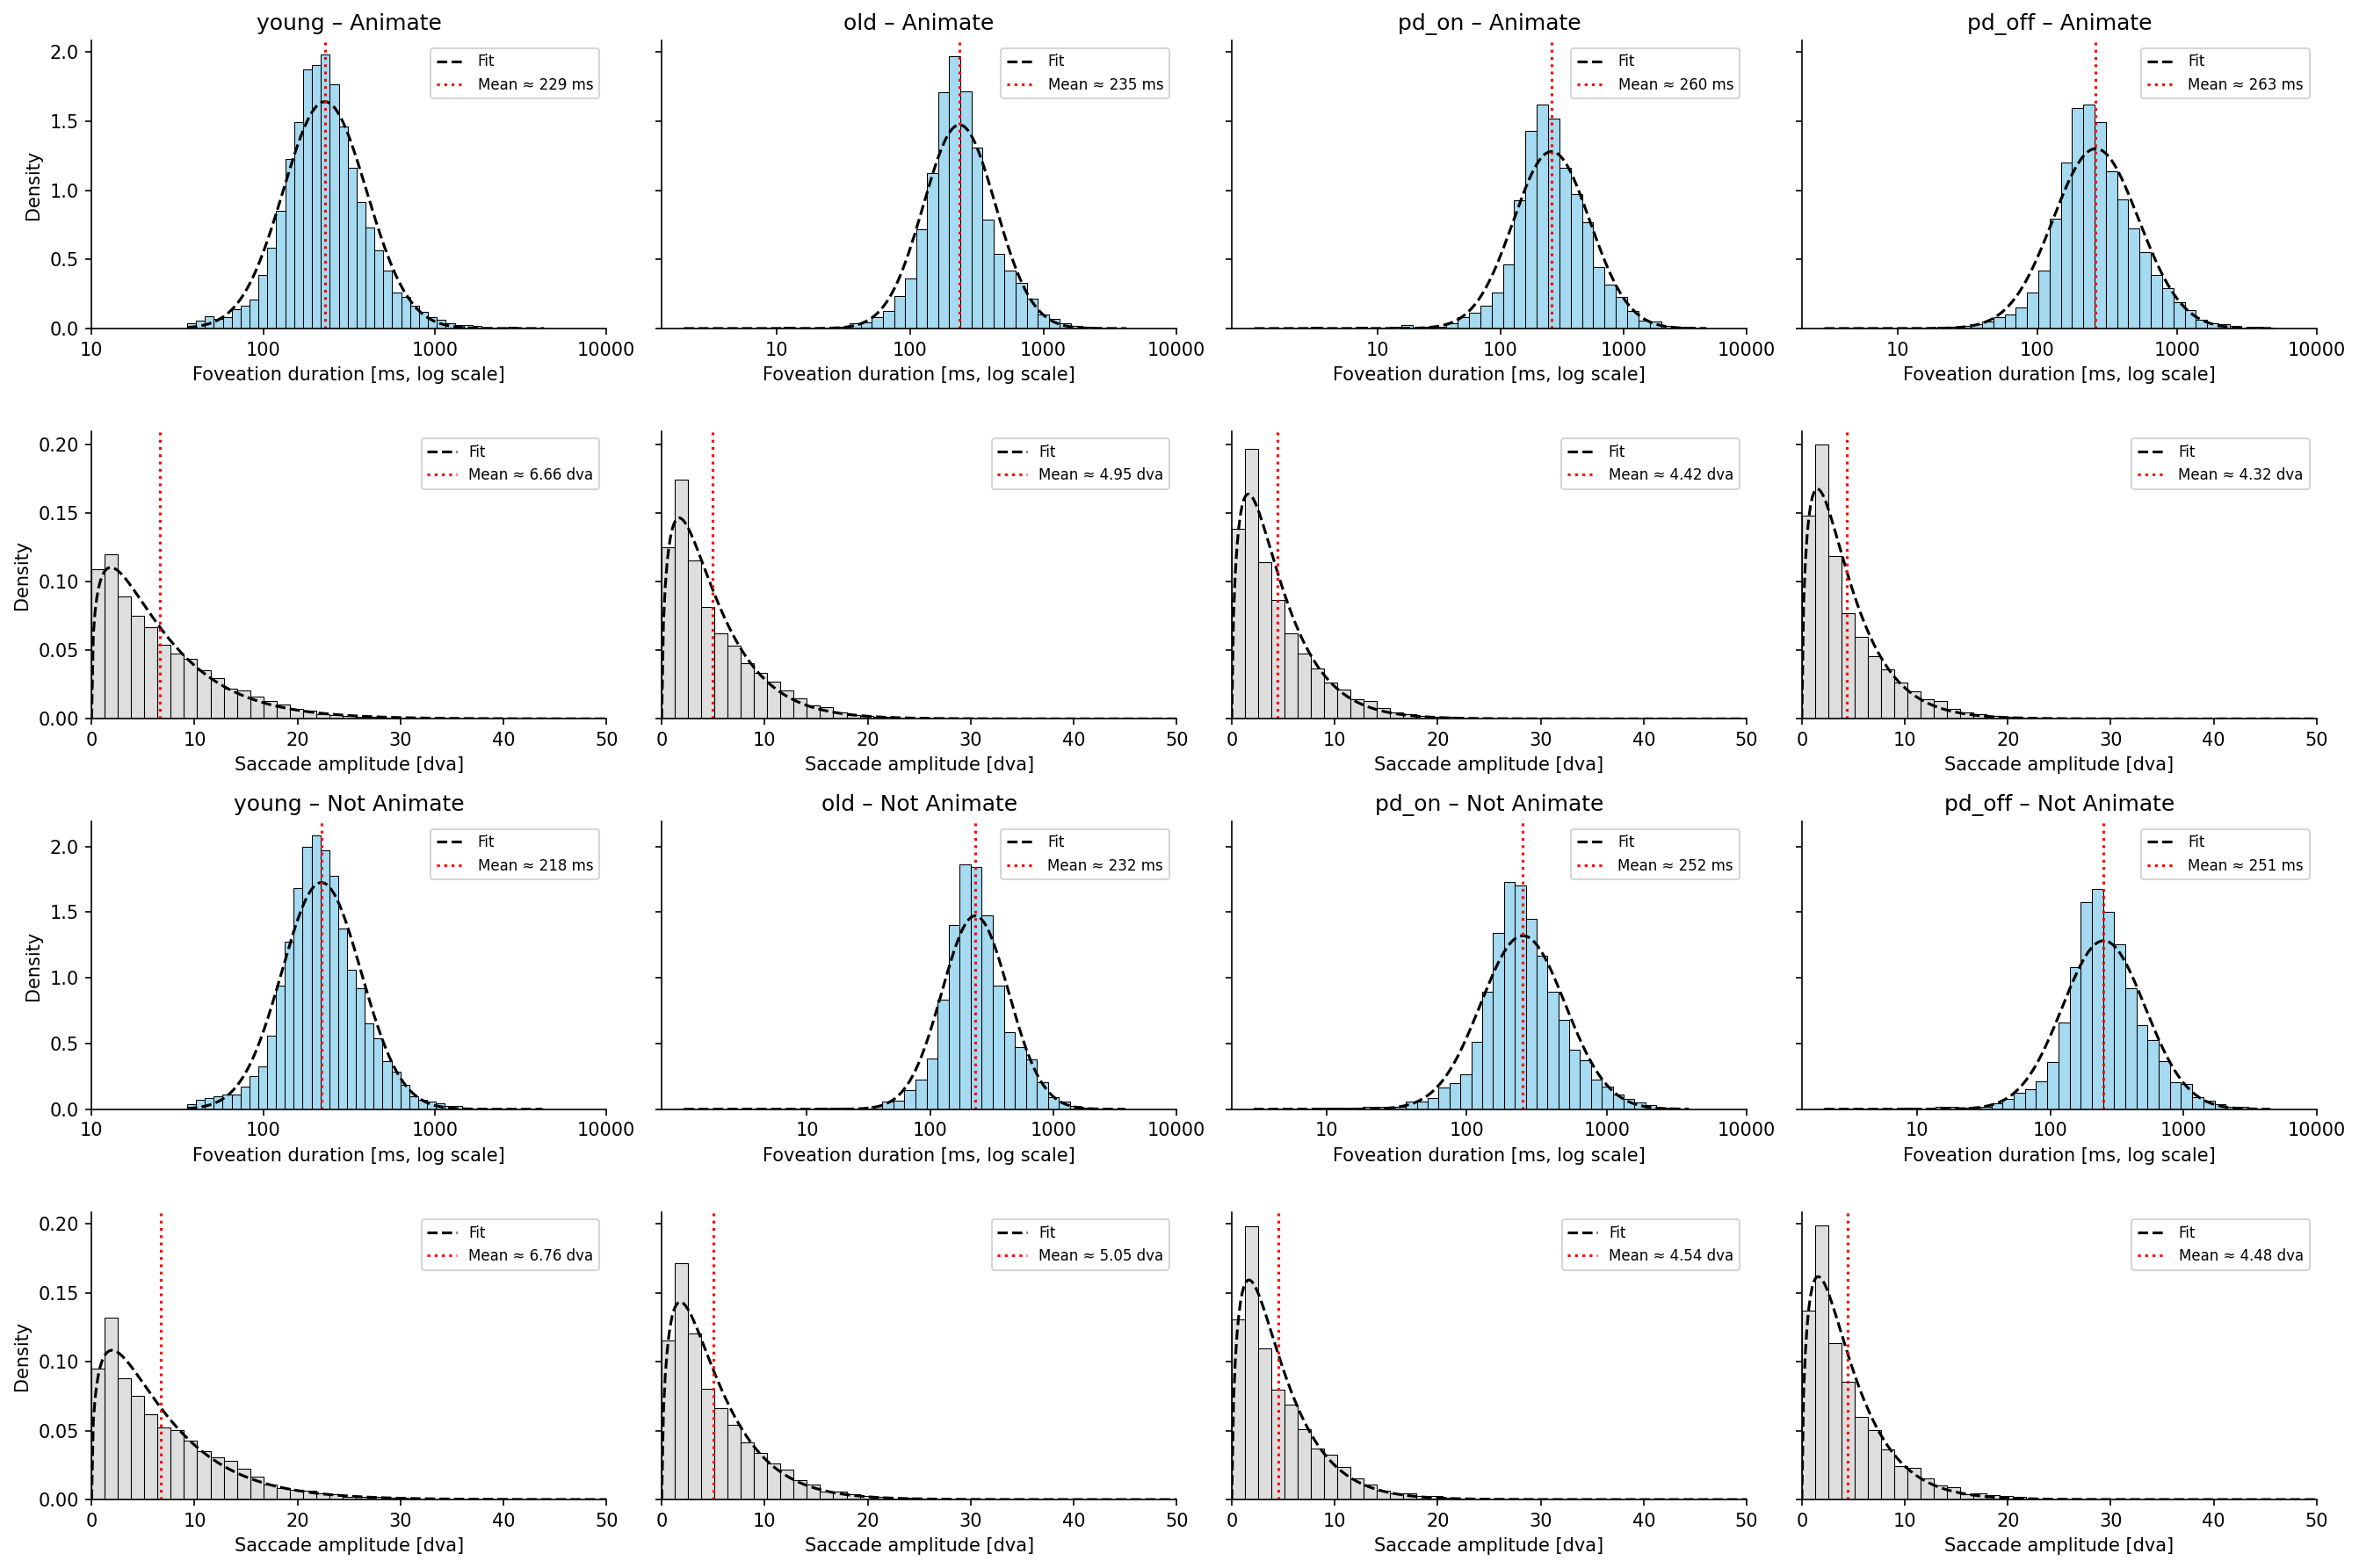

In [ ]:
conditions = [True, False]  # animated / not animated
condition_labels = ['Animate', 'Not Animate']

fig, axs = plt.subplots(4, len(VidCom.keys()), dpi=150, figsize=(18, 12),
                        sharey='row')

for col, key in enumerate(VidCom.keys()):
    data_set = VidCom[key].gt_foveation_df
    
    for row, cond in enumerate(conditions):
        df_cond = data_set[data_set['animate'] == cond]

        gt_amp = pd.to_numeric(df_cond["sac_amp_dva"], errors='coerce')
        gt_amp = gt_amp.dropna()
        gt_amp = gt_amp[gt_amp > 0.5]
        gt_dur = df_cond["duration_ms"].dropna().values
        gt_dur = gt_dur[np.isfinite(gt_dur) & (gt_dur > 0)]
        
        dur_log = np.log10(gt_dur)
        dur_mu, dur_sigma = stats.norm.fit(dur_log)
        amp_shape, amp_loc, amp_scale = stats.gamma.fit(gt_amp, floc=0)
        
        dur_x = np.linspace(dur_log.min(), dur_log.max(), 300)
        amp_x = np.linspace(0, 50, 300)

        print(f"\nDataset: {key}, Condition: {condition_labels[row]}")
        print(f"  Duration: n={len(gt_dur)}, mean={gt_dur.mean():.1f} ms, std={gt_dur.std():.1f} ms")
        print(f"    Fitted log-normal: mu={dur_mu:.3f}, sigma={dur_sigma:.3f}, mean ≈ {10**dur_mu:.1f} ms")
        print(f"  Amplitude: n={len(gt_amp)}, mean={gt_amp.mean():.2f} dva, std={gt_amp.std():.2f} dva")
        print(f"    Fitted gamma: shape={amp_shape:.3f}, scale={amp_scale:.3f}, mean ≈ {amp_shape*amp_scale:.2f} dva")
        

        ax_dur = axs[2*row, col]
        sns.histplot(dur_log, bins=40, ax=ax_dur, stat="density", color="skyblue")
        ax_dur.plot(dur_x, stats.norm.pdf(dur_x, dur_mu, dur_sigma), 'k--', label="Fit")
        mean_dur = 10**dur_mu
        ax_dur.axvline(dur_mu, color='red', linestyle=':', label=f"Mean ≈ {mean_dur:.0f} ms")
        ax_dur.set_xticks([1,2,3,4])
        ax_dur.set_xticklabels(["10","100","1000","10000"])
        ax_dur.set_xlabel("Foveation duration [ms, log scale]")
        ax_dur.set_title(f"{key} – {condition_labels[row]}")
        ax_dur.legend(fontsize=8)

        ax_amp = axs[2*row+1, col]
        sns.histplot(gt_amp, bins=np.linspace(0,50,40), stat="density", ax=ax_amp, color="lightgray")
        ax_amp.plot(amp_x, stats.gamma.pdf(amp_x, amp_shape, loc=0, scale=amp_scale), 'k--', label="Fit")
        mean_amp = amp_shape * amp_scale
        ax_amp.axvline(mean_amp, color='red', linestyle=':', label=f"Mean ≈ {mean_amp:.2f} dva")
        ax_amp.set_xlim(0, 50)
        ax_amp.set_xlabel("Saccade amplitude [dva]")
        ax_amp.legend(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

### Post-hoc analysis for Foveation Duration

In [10]:
# multiple pairwise comparision, normality assumption fullfilled after log

# Duration (log scale)
tukey_dur = pairwise_tukeyhsd(
    endog=stats_df["log_mean_dur"],
    groups=stats_df["group"]
)
print(tukey_dur)



Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   old pd_off   0.1401 0.0012  0.0445  0.2357   True
   old  pd_on     0.14 0.0009   0.046  0.2341   True
   old  young  -0.0895  0.053 -0.1797  0.0008  False
pd_off  pd_on  -0.0001    1.0 -0.0982  0.0981  False
pd_off  young  -0.2296    0.0 -0.3241 -0.1351   True
 pd_on  young  -0.2295    0.0 -0.3224 -0.1365   True
----------------------------------------------------


#### Seperated by Condition

In [11]:
# Separate comparisons by condition
for cond in ['Not Animate', 'Animate']:
    subset = stats_df[stats_df['condition'] == cond]
    tukey = pairwise_tukeyhsd(subset['log_mean_dur'], subset['group'])
    print(f"\n{cond}:")
    print(tukey)


Not Animate:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   old pd_off   0.1219 0.1002 -0.0156  0.2594  False
   old  pd_on   0.1228 0.0885 -0.0125  0.2581  False
   old  young  -0.1133 0.1085 -0.2431  0.0165  False
pd_off  pd_on   0.0009    1.0 -0.1402   0.142  False
pd_off  young  -0.2352 0.0001 -0.3711 -0.0993   True
 pd_on  young  -0.2361 0.0001 -0.3697 -0.1024   True
----------------------------------------------------

Animate:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   old pd_off   0.1583 0.0172  0.0212  0.2954   True
   old  pd_on   0.1572 0.0159  0.0223  0.2921   True
   old  young  -0.0657 0.5436 -0.1951  0.0638  False
pd_off  pd_on   -0.001    1.0 -0.1418  0.1397  False
pd_off  young  -0.2239 0.0003 -0.3595 -0.0884   True
 pd_on  young  -0.2229

In [ ]:
#Independent t-test with Bonferroni correction for multiple comparisons:

def test_within_group_with_correction(stats_df, method='paired'):
    """
    Test each group with Bonferroni correction for multiple comparisons.
    
    Parameters:
    -----------
    stats_df : pandas.DataFrame
        DataFrame with columns: group, condition, log_mean_dur
    method : str, default='paired'
        'paired' for paired t-test, 'independent' for independent t-test, 
        'nonparametric' for Wilcoxon/Mann-Whitney
    """
    print(f"WITHIN-GROUP COMPARISONS with Bonferroni Correction ({method})")
    print("="*70)
    
    groups = stats_df['group'].unique()
    n_comparisons = len(groups)
    alpha = 0.05
    bonferroni_alpha = alpha / n_comparisons

    results = []
    
    for group in groups:
        group_data = stats_df[stats_df['group'] == group]
        
        # Get animated and not animated data
        animated = group_data[group_data['condition'] == 'Animate']['log_mean_dur'].values
        not_animated = group_data[group_data['condition'] == 'Not Animate']['log_mean_dur'].values
        
        if method == 'paired' and len(animated) == len(not_animated):
            stat, p_value = ttest_rel(animated, not_animated)
            test_name = "Paired t-test"
        elif method == 'independent' or (method == 'paired' and len(animated) != len(not_animated)):
            stat, p_value = ttest_ind(animated, not_animated)
            test_name = "Independent t-test"
        elif method == 'nonparametric':
            if len(animated) == len(not_animated):
                stat, p_value = wilcoxon(animated, not_animated)
                test_name = "Wilcoxon signed-rank"
            else:
                stat, p_value = mannwhitneyu(animated, not_animated, alternative='two-sided')
                test_name = "Mann-Whitney U"
        
        results.append({
            'group': group,
            'test': test_name,
            'n_animated': len(animated),
            'n_not_animated': len(not_animated),
            'mean_animated': np.mean(animated),
            'mean_not_animated': np.mean(not_animated),
            'statistic': stat,
            'p_value': p_value,
            'significant_uncorrected': p_value < alpha,
            'significant_bonferroni': p_value < bonferroni_alpha
        })
        
        print(f"\n{group}:")
        print(f"  Test: {test_name}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Significant (α=0.05): {'Yes' if p_value < alpha else 'No'}")
        print(f"  Significant (Bonferroni α={bonferroni_alpha:.4f}): {'Yes' if p_value < bonferroni_alpha else 'No'}")
    

    return 

results = test_within_group_with_correction(stats_df, method='independent')

WITHIN-GROUP COMPARISONS with Bonferroni Correction (independent)

young:
  Test: Independent t-test
  p-value: 0.1150
  Significant (α=0.05): No
  Significant (Bonferroni α=0.0125): No

old:
  Test: Independent t-test
  p-value: 0.7764
  Significant (α=0.05): No
  Significant (Bonferroni α=0.0125): No

pd_on:
  Test: Independent t-test
  p-value: 0.4315
  Significant (α=0.05): No
  Significant (Bonferroni α=0.0125): No

pd_off:
  Test: Independent t-test
  p-value: 0.4451
  Significant (α=0.05): No
  Significant (Bonferroni α=0.0125): No


### Post-hoc analysis for Saccade Amplitude

In [13]:
# Kruskal-Wallis (non-parametric ANOVA, as data isnt normal distributed)
groups = [stats_df[stats_df['group']==g]['mean_amp'].values 
          for g in ['young', 'old', 'pd_on', 'pd_off']]
h_stat, p_val = sp_stats.kruskal(*groups)
print(f"Kruskal-Wallis H={h_stat:.3f}, p={p_val:.4f}")

# Dunn's post-hoc test 
dunn_result = posthoc_dunn(
    stats_df, 
    val_col='mean_amp', 
    group_col='group',
    p_adjust='holm'  # or 'holm', 'fdr_bh', 'bonferroni'
)
print(dunn_result)

groups_list = ['young', 'old', 'pd_on', 'pd_off']
for i, g1 in enumerate(groups_list):
    for g2 in groups_list[i+1:]:
        p_value = dunn_result.loc[g1, g2]
        significant = p_value < 0.05
        symbol = "✓ SIGNIFICANT" if significant else "✗ Not significant"
        print(f"{g1:8} vs {g2:8}: p = {p_value:.4f}  {symbol}")

Kruskal-Wallis H=86.522, p=0.0000
                 old         young         pd_on        pd_off
old     1.000000e+00  2.367211e-09  1.709647e-01  1.709647e-01
young   2.367211e-09  1.000000e+00  1.211915e-14  4.963768e-14
pd_on   1.709647e-01  1.211915e-14  1.000000e+00  9.469322e-01
pd_off  1.709647e-01  4.963768e-14  9.469322e-01  1.000000e+00
young    vs old     : p = 0.0000  ✓ SIGNIFICANT
young    vs pd_on   : p = 0.0000  ✓ SIGNIFICANT
young    vs pd_off  : p = 0.0000  ✓ SIGNIFICANT
old      vs pd_on   : p = 0.1710  ✗ Not significant
old      vs pd_off  : p = 0.1710  ✗ Not significant
pd_on    vs pd_off  : p = 0.9469  ✗ Not significant


### Temporal Trends


YOUNG (N=20 subjects):
  Amplitude: mean_r=-0.010, p=0.4372 n.s.
             SD=0.052, range=[-0.067, 0.165]
  Duration:  mean_r=0.022, p=0.0262 *
             SD=0.040, range=[-0.060, 0.129]

OLD (N=19 subjects):
  Amplitude: mean_r=-0.040, p=0.0113 *
             SD=0.060, range=[-0.249, 0.043]
  Duration:  mean_r=0.008, p=0.3659 n.s.
             SD=0.039, range=[-0.040, 0.091]

PD_ON (N=17 subjects):
  Amplitude: mean_r=-0.087, p=0.0001 ***
             SD=0.070, range=[-0.221, 0.034]
  Duration:  mean_r=0.024, p=0.0406 *
             SD=0.044, range=[-0.048, 0.088]

PD_OFF (N=16 subjects):
  Amplitude: mean_r=-0.067, p=0.0003 ***
             SD=0.055, range=[-0.146, 0.017]
  Duration:  mean_r=0.003, p=0.8057 n.s.
             SD=0.047, range=[-0.084, 0.070]


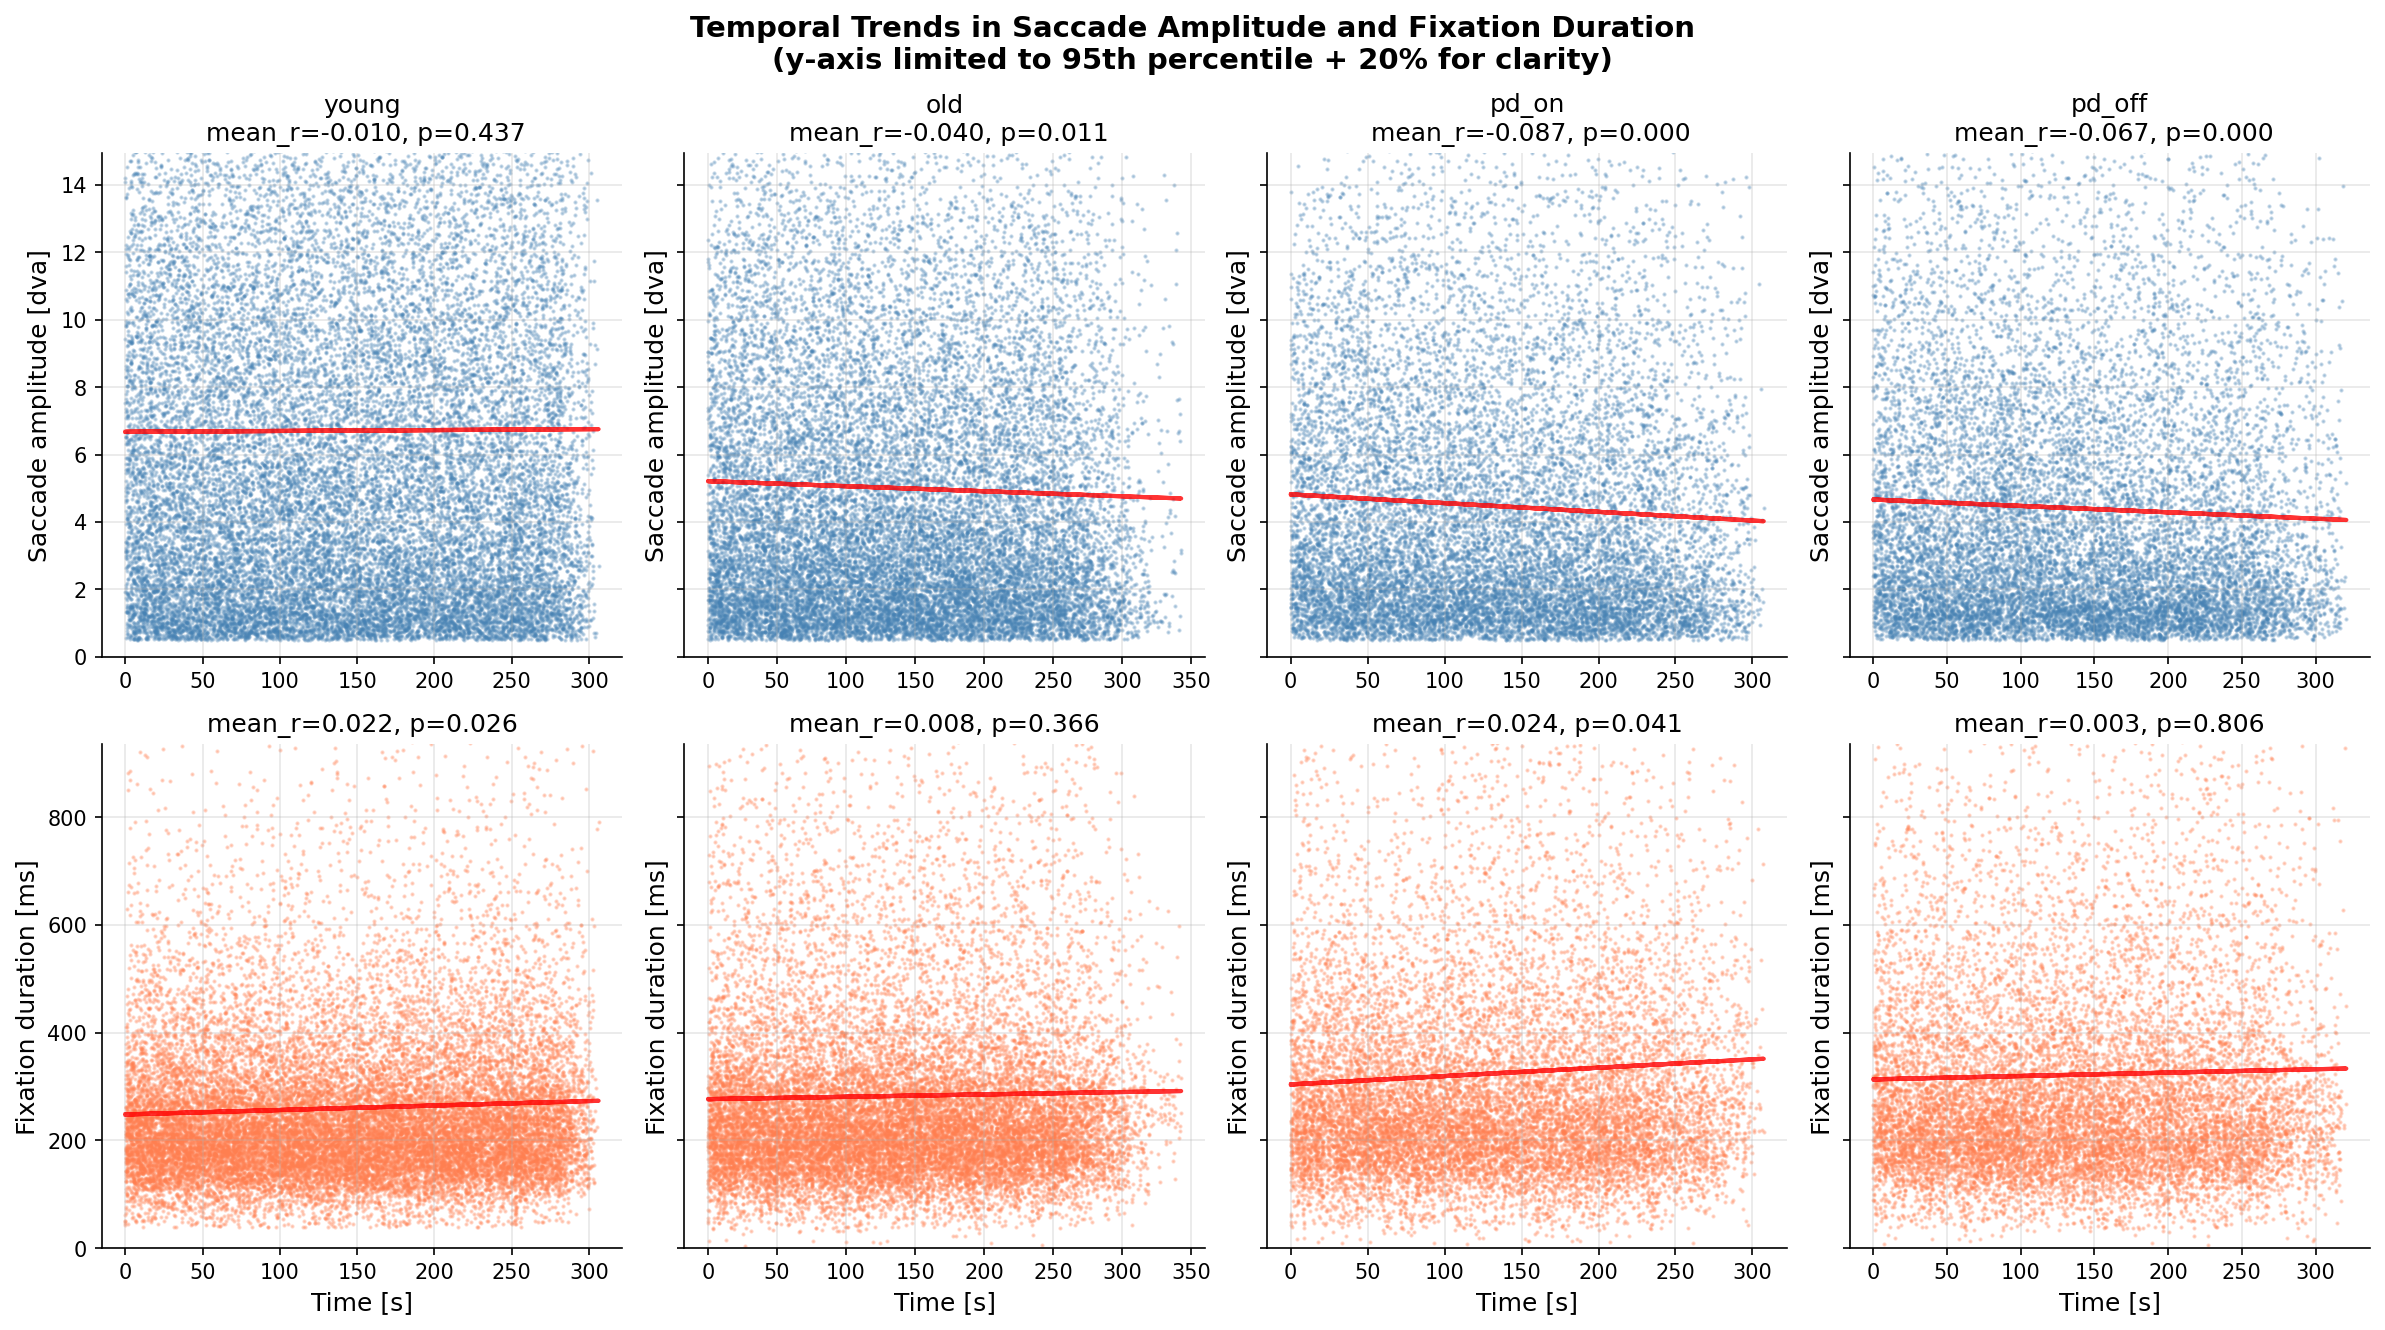

In [ ]:

fig, axs = plt.subplots(2, len(VidCom.keys()), dpi=150, figsize=(16, 9), sharey='row')
fig.suptitle('Temporal Trends in Saccade Amplitude and Fixation Duration\n(y-axis limited to 95th percentile + 20% for clarity)', 
             fontsize=14, fontweight='bold')

for col, key in enumerate(VidCom.keys()):
    data_set = VidCom[key]
    df = data_set.gt_foveation_df.copy()
    df = df[df["sac_amp_dva"] > 0.5].dropna(subset=["sac_amp_dva", "duration_ms"])
    df = df[np.isfinite(df["duration_ms"]) & (df["duration_ms"] > 0)]
    
    if "time_ms" not in df.columns:
        if "subject" in df.columns:
            df["time_ms"] = df.groupby("subject")["duration_ms"].cumsum()
        elif "subj_id" in df.columns:
            df["time_ms"] = df.groupby("subj_id")["duration_ms"].cumsum()
        else:
            df["time_ms"] = df["duration_ms"].cumsum()
    
    time_s = df["time_ms"] / 1000
    
    # Calculate correlation FOR EACH SUBJECT (try to account for dependency between saccades)
    subj_col = "subject" if "subject" in df.columns else "subj_id"
    
    amp_corrs = []
    dur_corrs = []
    
    for subj in df[subj_col].unique():
        subj_data = df[df[subj_col] == subj]
        if len(subj_data) > 30:  
            r_amp, _ = spearmanr(subj_data["time_ms"], subj_data["sac_amp_dva"])
            r_dur, _ = spearmanr(subj_data["time_ms"], subj_data["duration_ms"])
            amp_corrs.append(r_amp)
            dur_corrs.append(r_dur)
    
    amp_mean = np.mean(amp_corrs)
    dur_mean = np.mean(dur_corrs)
    
    amp_t, amp_p = ttest_1samp(amp_corrs, 0)
    dur_t, dur_p = ttest_1samp(dur_corrs, 0)
    
    amp_95 = np.percentile(df["sac_amp_dva"], 95)
    dur_95 = np.percentile(df["duration_ms"], 95)

    # Plot 1: Amplitude over time (scatter + trend line)
    axs[0, col].scatter(time_s, df["sac_amp_dva"], alpha=0.3, s=1, color='steelblue')

    z = np.polyfit(time_s, df["sac_amp_dva"], 1)
    p = np.poly1d(z)
    axs[0, col].plot(time_s, p(time_s), "r-", linewidth=2, alpha=0.8)
    axs[0, col].set_ylabel('Saccade amplitude [dva]', size=12)
    axs[0, col].set_title(f'{key}\n mean_r={amp_mean:.3f}, p={amp_p:.3f}', size=12)
    axs[0, col].grid(alpha=0.3)
    
    # Plot 2: Duration over time (scatter + trend line)
    axs[1, col].scatter(time_s, df["duration_ms"], alpha=0.3, s=1, color='coral')
    z = np.polyfit(time_s, df["duration_ms"], 1)
    p = np.poly1d(z)
    axs[1, col].plot(time_s, p(time_s), "r-", linewidth=2, alpha=0.8)
    axs[1, col].set_ylabel('Fixation duration [ms]', size=12)
    axs[1, col].set_xlabel('Time [s]', size=12)
    axs[1, col].set_title(f'mean_r={dur_mean:.3f}, p={dur_p:.3f}', size=12)
    axs[1, col].grid(alpha=0.3)
    
    
    axs[0, col].set_ylim(0, amp_95 * 1.2)  # Show up to 95th percentile + 20%
    axs[1, col].set_ylim(0, dur_95 * 1.2)
    
    print(f"\n{key.upper()} (N={len(amp_corrs)} subjects):")
    print(f"  Amplitude: mean_r={amp_mean:.3f}, p={amp_p:.4f} {'***' if amp_p < 0.001 else '**' if amp_p < 0.01 else '*' if amp_p < 0.05 else 'n.s.'}")
    print(f"             SD={np.std(amp_corrs):.3f}, range=[{min(amp_corrs):.3f}, {max(amp_corrs):.3f}]")
    print(f"  Duration:  mean_r={dur_mean:.3f}, p={dur_p:.4f} {'***' if dur_p < 0.001 else '**' if dur_p < 0.01 else '*' if dur_p < 0.05 else 'n.s.'}")
    print(f"             SD={np.std(dur_corrs):.3f}, range=[{min(dur_corrs):.3f}, {max(dur_corrs):.3f}]")

sns.despine()
plt.tight_layout()
plt.show()

## Analysis Saccade Angle

/tmp/ipykernel_9365/2491503122.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9365/2491503122.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


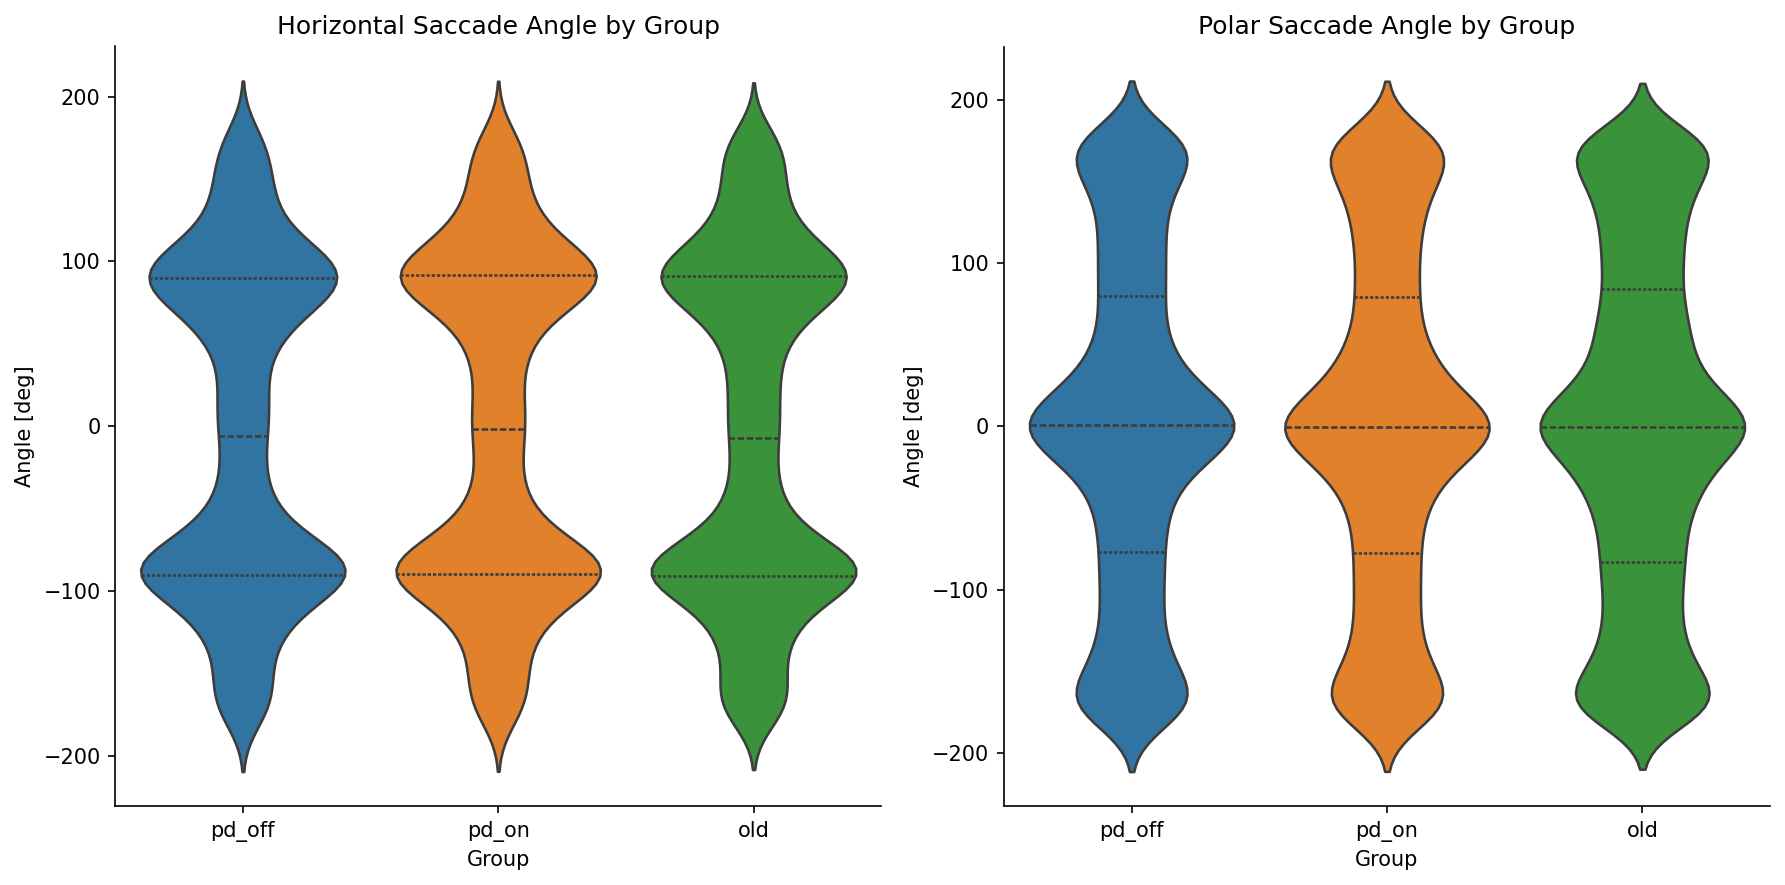

In [15]:
groups = ['pd_off', 'pd_on', 'old']
angles = ['sac_angle_h', 'sac_angle_p']
angle_labels = ['Horizontal Saccade Angle', 'Polar Saccade Angle']

dfs = []

for key in groups:
    df = VidCom[key].gt_foveation_df[['sac_angle_h', 'sac_angle_p']].copy()
    df['group'] = key  
    dfs.append(df)

df_plot = pd.concat(dfs, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=150)

for ax, angle, label in zip(axes, angles, angle_labels):
    sns.violinplot(
        x='group',
        y=angle,
        data=df_plot,
        ax=ax,
        inner='quartile',
        palette={'pd_off': 'C0', 'pd_on': 'C1', 'old': 'C2'}
    )
    
    ax.set_title(f'{label} by Group')
    ax.set_ylabel('Angle [deg]')
    ax.set_xlabel('Group')

plt.tight_layout()
sns.despine()
plt.show()


## Analysis Foveation Categories (BDIR)

In [ ]:
def plot_fovcat_ratios(VidCom, dircl, split_train_test=False, animate=None):
    """
    Plot BDIR ratio bar charts for foveation categories.
    
    Parameters:
    -----------
    VidCom : dict
        Dictionary containing video data with get_fovcat_ratio method
    dircl : list
        List of colors for each BDIR category [B, D, I, R]
    split_train_test : bool, default=False
        If True, create two side-by-side plots for train and test sets
        If False, create single plot with combined (averaged) train/test data
    animate : bool or None, default=None
        If True, only include animated data (where 'animate' column == True)
        If False, only include non-animated data (where 'animate' column == False)
        If None, include all data regardless of animation status
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    df_fovcats : pandas.DataFrame or dict of DataFrames
        If split_train_test=False: Single DataFrame with combined data
        If split_train_test=True: Dict with keys 'train' and 'test'
    """
    groups = VidCom.keys()
    
    def get_filtered_fovcat_ratio(vidcom_obj, split, animate_filter=None):
        """Get fovcat ratio with optional animation filtering."""
        if animate_filter is None:
            return list(vidcom_obj.get_fovcat_ratio(split).values())
        else: 
            if split == "train":
                df = vidcom_obj.train_foveation_df
            else:
                df = vidcom_obj.test_foveation_df
            
            
            if 'animate' in df.columns:
                df = df[df['animate'] == animate_filter]
           
            cat_col = 'fov_category' if 'fov_category' in df.columns else 'fov_cat'
            if len(df) == 0:
                return [0.0, 0.0, 0.0, 0.0]
            
            counts = df[cat_col].value_counts()
            total = len(df)
            ratios = {
                'B': counts.get('B', 0) / total if total > 0 else 0,
                'D': counts.get('D', 0) / total if total > 0 else 0,
                'I': counts.get('I', 0) / total if total > 0 else 0,
                'R': counts.get('R', 0) / total if total > 0 else 0,
            }
            return [ratios['B'], ratios['D'], ratios['I'], ratios['R']]
    
    
    legend_handles = [
        mpatches.Patch(color=dircl[0], label='Background'),
        mpatches.Patch(color=dircl[1], label='Detection'),
        mpatches.Patch(color=dircl[2], label='Inspection'),
        mpatches.Patch(color=dircl[3], label='Return'),
    ]
    

    def plot_with_labels(df, ax, alpha=1.0):
        """Plot horizontal stacked bar chart with value labels inside bars."""
        bars = ax.barh(
            df.index,
            df['B'], color=dircl[0], alpha=alpha
        )
        bars_D = ax.barh(
            df.index,
            df['D'], left=df['B'], color=dircl[1], alpha=alpha
        )
        bars_I = ax.barh(
            df.index,
            df['I'], left=df[['B','D']].sum(axis=1), color=dircl[2], alpha=alpha
        )
        bars_R = ax.barh(
            df.index,
            df['R'], left=df[['B','D','I']].sum(axis=1), color=dircl[3], alpha=alpha
        )
        

        def add_labels(bars, values, left):
            for bar, val, start in zip(bars, values, left):
                if val == 0:
                    continue  # skip spacer row
                x = start + val/2
                y = bar.get_y() + bar.get_height()/2
                color = "white" if val > 0.15 else "black"  
                ax.text(x, y, f"{val:.2f}", ha='center', va='center', fontsize=7, color=color)
        
 
        add_labels(bars, df['B'], np.zeros(len(df)))
        add_labels(bars_D, df['D'], df['B'])
        add_labels(bars_I, df['I'], df[['B','D']].sum(axis=1))
        add_labels(bars_R, df['R'], df[['B','D','I']].sum(axis=1))
    
    if split_train_test:
        train_rows = []
        test_rows = []
        labels = []
        
        for key in groups:
            # Get human data with optional animate filtering
            human_train = get_filtered_fovcat_ratio(VidCom[key], "train", animate)
            human_test = get_filtered_fovcat_ratio(VidCom[key], "test", animate)
            
            train_rows.append(human_train)
            test_rows.append(human_test)
            
            label_suffix = " (Animated)" if animate is True else " (Not Animated)" if animate is False else ""
            labels.append(f"{key} – Human{label_suffix}")
        
        df_fovcats_train = pd.DataFrame(train_rows, index=labels, columns=['B','D','I','R'])
        df_fovcats_test  = pd.DataFrame(test_rows,  index=labels, columns=['B','D','I','R'])
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150, sharey=True)
        
        plot_with_labels(df_fovcats_train, axes[0], alpha=1.0)
        axes[0].set_title("Training set")
        axes[0].set_xlabel("Ratio of events")
        axes[0].set_frame_on(False)
        
        plot_with_labels(df_fovcats_test, axes[1], alpha=0.7)
        axes[1].set_title("Test set")
        axes[1].set_xlabel("Ratio of events")
        axes[1].set_frame_on(False)
        
        df_fovcats = {'train': df_fovcats_train, 'test': df_fovcats_test}
        
    else:
        combined_rows = []
        combined_labels = []
        
        for key in groups:
            human_train = get_filtered_fovcat_ratio(VidCom[key], "train", animate)
            human_test = get_filtered_fovcat_ratio(VidCom[key], "test", animate)
            
            combined = [(t + s) / 2 for t, s in zip(human_train, human_test)]
            
            combined_rows.append(combined)
            
            label_suffix = " (Animated)" if animate is True else " (Not Animated)" if animate is False else ""
            combined_labels.append(f"{key} – Human{label_suffix}")
        
        df_fovcats_combined = pd.DataFrame(combined_rows, index=combined_labels, columns=['B','D','I','R'])
        
        fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
        
        plot_with_labels(df_fovcats_combined, ax, alpha=0.85)
        
        title = "Combined (Train + Test)"
        if animate is True:
            title += " – Animated"
        elif animate is False:
            title += " – Not Animated"
        ax.set_title(title)
        ax.set_xlabel("Ratio of events")
        ax.set_frame_on(False)
        
        df_fovcats = df_fovcats_combined
    
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,
        bbox_to_anchor=(0.5, -0.07)
    )
    
    plt.tight_layout()
    
    return fig, df_fovcats


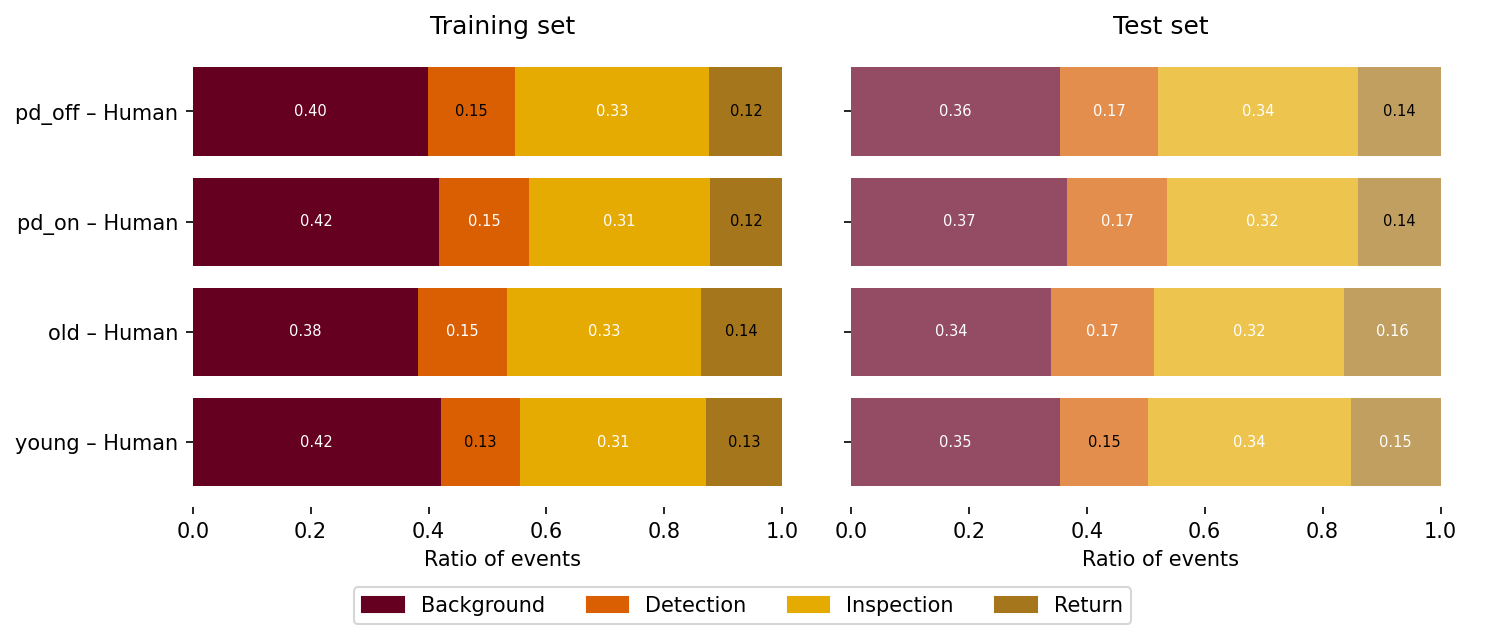

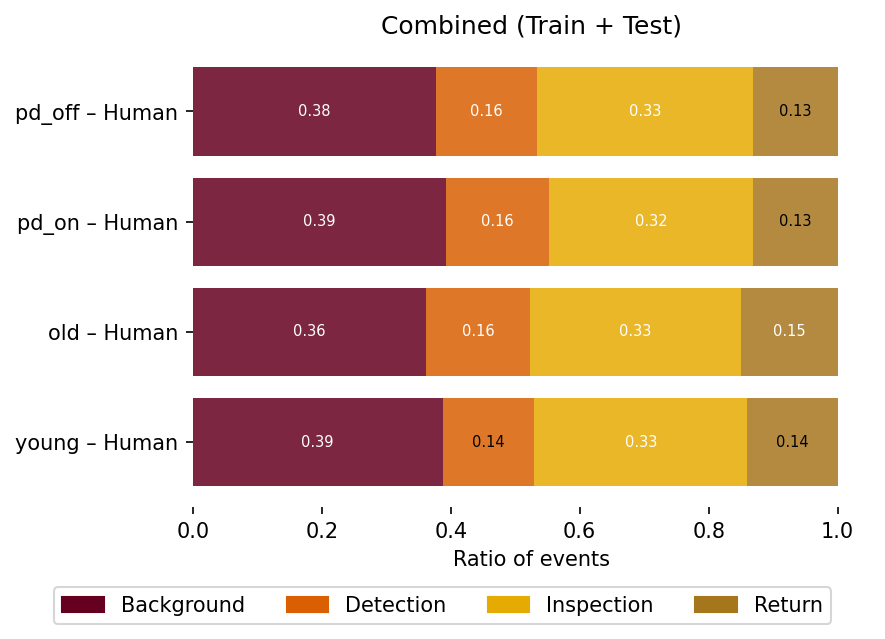

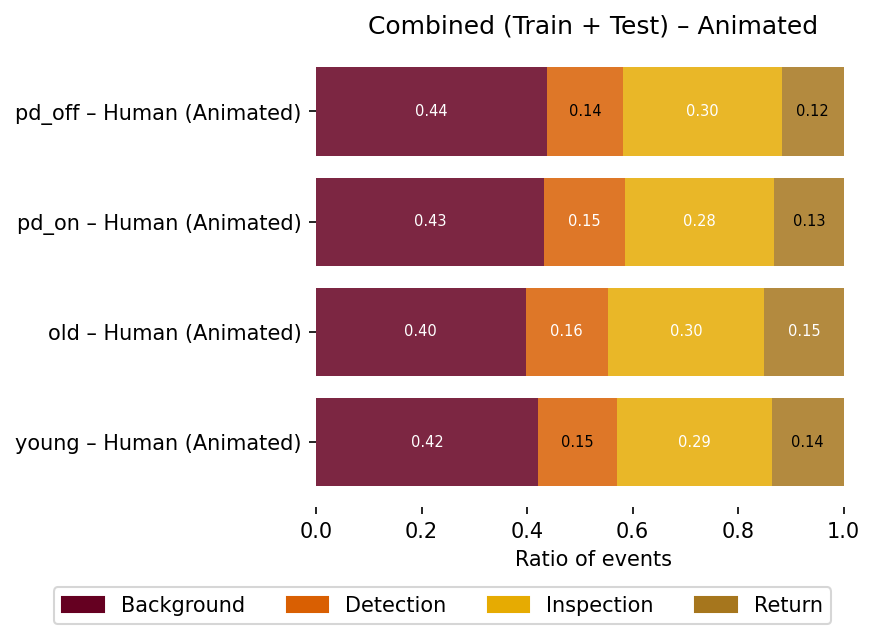

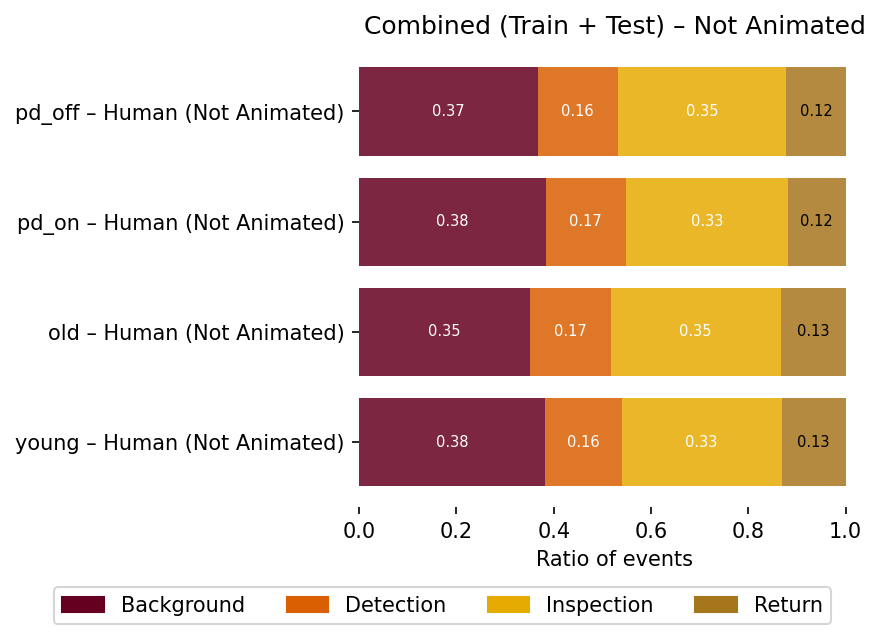

In [17]:
# Plot with separate train/test data (all data)
fig, dfs = plot_fovcat_ratios(VidCom, dircl, split_train_test=True)
plt.show()

# Plot with combined train/test data (all data)
fig, df = plot_fovcat_ratios(VidCom, dircl, split_train_test=False)
plt.show()

# Plot combined data, only animated
fig, df = plot_fovcat_ratios(VidCom, dircl, split_train_test=False, animate=True)
plt.show()

# Plot combined data, only non-animated
fig, df = plot_fovcat_ratios(VidCom, dircl, split_train_test=False, animate=False)
plt.show()


### BDIR timecourse

In [ ]:
def find_intersections(x, y1, y2):
    """
    Find intersection points between two lines.
    Returns arrays of x and y coordinates where lines intersect.
    """
    intersections_x = []
    intersections_y = []
    
    for i in range(len(x) - 1):
        if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
            # Linear interpolation to find exact intersection point
            x1, x2 = x[i], x[i+1]
            # Solve for intersection using linear interpolation
            t = (y2[i] - y1[i]) / ((y1[i+1] - y1[i]) - (y2[i+1] - y2[i]))
            if 0 <= t <= 1:
                x_intersect = x1 + t * (x2 - x1)
                y_intersect = y1[i] + t * (y1[i+1] - y1[i])
                intersections_x.append(x_intersect)
                intersections_y.append(y_intersect)
    
    return np.array(intersections_x), np.array(intersections_y)


def get_BDIR_per_frames(df, fps=30, animate=None):
    """
    Calculate BDIR ratios per frame from foveation dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing foveation data
    fps : int, default=30
        Frames per second
    animate : bool or None, default=None
        If True, only include animated data (where 'animate' column == True)
        If False, only include non-animated data (where 'animate' column == False)
        If None, include all data regardless of animation status
    
    Returns:
    --------
    BDIR_ratios_per_frames : numpy.ndarray
        Array of shape (4, n_frames) with BDIR percentages per frame
    """
    # Filter by animation status if specified
    if animate is not None and 'animate' in df.columns:
        df = df[df['animate'] == animate].copy()
    
    # Determine column names
    cat_col = 'fov_category' if 'fov_category' in df.columns else 'fov_cat'
    start_col = 'frame_start' if 'frame_start' in df.columns else 't_start'
    end_col = 'frame_end' if 'frame_end' in df.columns else 't_end'
    use_ms = start_col == 't_start'
    # Determine the maximum frame number to set array size
    if use_ms:
        max_frame = int(df[end_col].max()/ 1000 * fps ) + 1
    else:
        max_frame = int(df[end_col].max()) + 1
    BDIR_per_frames = np.zeros((4, max_frame))
    bdir_to_row = {'B': 0, 'D': 1, 'I': 2, 'R': 3}
    for index, row in df.iterrows():
        if use_ms:
            # Convert milliseconds to frames
            frame_start = int(row[start_col]/ 1000  * fps )
            frame_end = int(row[end_col]/ 1000  * fps )
        else:
            frame_start = int(row[start_col])
            frame_end = int(row[end_col])
        
        # Ensure indices are within bounds
        frame_start = max(0, min(frame_start, max_frame - 1))
        frame_end = max(0, min(frame_end, max_frame - 1))
        
        BDIR_per_frames[bdir_to_row[row[cat_col]], frame_start:frame_end+1] += 1
    # Avoid division by zero
    denominator = np.sum(BDIR_per_frames, axis=0)
    denominator[denominator == 0] = 1
    BDIR_ratios_per_frames = 100 * BDIR_per_frames / denominator
    return BDIR_ratios_per_frames


def plot_BDIR_over_time(VidCom, dircl, split_train_test=False, fps=30, animate=None):
    """
    Plot BDIR (Background, Detection, Inspection, Revisit) ratios over time.
    
    Parameters:
    -----------
    VidCom : dict
        Dictionary containing video data with train_foveation_df and test_foveation_df
    dircl : list
        List of colors for each BDIR category
    split_train_test : bool, default=False
        If True, plot train and test data separately (train with transparency)
        If False, plot combined average of train and test data
    fps : int, default=30
        Frames per second for time conversion
    animate : bool or None, default=None
        If True, only include animated data (where 'animate' column == True)
        If False, only include non-animated data (where 'animate' column == False)
        If None, include all data regardless of animation status
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    intersection_summary : dict
        Dictionary containing intersection points and max values for each video
    """
    dirnames = ['Background', 'Detection', 'Inspection', 'Revisit']
    names = list(VidCom.keys())
    n_plots = len(names)
    
    fig, axs = plt.subplots(
        int(n_plots/2), 2,
        dpi=200,
        figsize=(9, 2.5 * int(n_plots/2)),
        sharex=True,
        sharey=True
    )
    axs = np.atleast_1d(axs)
    axs = axs.flatten()


    intersection_summary = {}

    for key_idx, key in enumerate(names):
        ax = axs[key_idx]
        

        title_suffix = " – Animated" if animate is True else " – Not Animated" if animate is False else ""
        ax.set_title(f'{key} – Human data{title_suffix}', fontsize=12)
        
        ratios_train = get_BDIR_per_frames(VidCom[key].train_foveation_df, fps=fps, animate=animate)
        ratios_test = get_BDIR_per_frames(VidCom[key].test_foveation_df, fps=fps, animate=animate)
        n_frames = ratios_train.shape[1]
        x_s = np.arange(n_frames)/fps
        x_ms = x_s * 1000
        
        if split_train_test:

            for i in range(4):
                # Train with semi-transparent line
                ax.plot(
                    x_ms,
                    ratios_train[i],
                    color=dircl[i],
                    lw=2,
                    alpha=0.25,
                    marker='o',
                    markersize=3
                )
                # Test
                ax.plot(
                    x_ms,
                    ratios_test[i],
                    color=dircl[i],
                    lw=2,
                    marker='o',
                    markersize=3
                )
            
            # Initialize intersection summary for split mode
            intersection_summary[key] = {
                'train': [],
                'test': [],
                'max_values': {
                    'train': {},
                    'test': {}
                }
            }
            
            # Find train-train intersections
            for i in range(4):
                for j in range(i+1, 4):
                    int_x, int_y = find_intersections(x_ms, ratios_train[i], ratios_train[j])
                    if len(int_x) > 0:
                        for x_val, y_val in zip(int_x, int_y):
                            intersection_summary[key]['train'].append({
                                'line1': dirnames[i],
                                'line2': dirnames[j],
                                'time_ms': x_val,
                                'percentage': y_val
                            })
            
            # Find test-test intersections
            for i in range(4):
                for j in range(i+1, 4):
                    int_x, int_y = find_intersections(x_ms, ratios_test[i], ratios_test[j])
                    if len(int_x) > 0:
                        for x_val, y_val in zip(int_x, int_y):
                            intersection_summary[key]['test'].append({
                                'line1': dirnames[i],
                                'line2': dirnames[j],
                                'time_ms': x_val,
                                'percentage': y_val
                            })
            
            # Calculate max values for each line
            for i in range(4):
                max_train = np.max(ratios_train[i])
                max_train_time = x_ms[np.argmax(ratios_train[i])]
                intersection_summary[key]['max_values']['train'][dirnames[i]] = {
                    'max_percentage': max_train,
                    'time_ms': max_train_time
                }
                
                max_test = np.max(ratios_test[i])
                max_test_time = x_ms[np.argmax(ratios_test[i])]
                intersection_summary[key]['max_values']['test'][dirnames[i]] = {
                    'max_percentage': max_test,
                    'time_ms': max_test_time
                }
        
        else:
            ratios_combined = (ratios_train + ratios_test) / 2
            
            for i in range(4):
                ax.plot(
                    x_ms,
                    ratios_combined[i],
                    color=dircl[i],
                    lw=2,
                    marker='o',
                    markersize=3,
                    label=dirnames[i]
                )
            
            intersection_summary[key] = {
                'intersections': [],
                'max_values': {}
            }
            
            # Find intersections for combined data
            for i in range(4):
                for j in range(i+1, 4):
                    int_x, int_y = find_intersections(x_ms, ratios_combined[i], ratios_combined[j])
                    if len(int_x) > 0:
                        for x_val, y_val in zip(int_x, int_y):
                            intersection_summary[key]['intersections'].append({
                                'line1': dirnames[i],
                                'line2': dirnames[j],
                                'time_ms': x_val,
                                'percentage': y_val
                            })
            
            # Calculate max values for each line
            for i in range(4):
                max_combined = np.max(ratios_combined[i])
                max_combined_time = x_ms[np.argmax(ratios_combined[i])]
                intersection_summary[key]['max_values'][dirnames[i]] = {
                    'max_percentage': max_combined,
                    'time_ms': max_combined_time
                }
        
        ax.set_ylabel('Percentage')
        ax.set_ylim(0, 100)
        ax.grid(True, linestyle='--', alpha=0.5)

    axs[-1].set_xlabel('Time [ms]')

    if split_train_test:
        train_lines = [
            plt.Line2D([0], [0], color=dircl[i], lw=2, alpha=0.25)
            for i in range(4)
        ]
        test_lines = [
            plt.Line2D([0], [0], color=dircl[i], lw=2)
            for i in range(4)
        ]
        legend_handles = [
            (test_lines[i], train_lines[i]) for i in range(4)
        ]
        fig.legend(
            legend_handles,
            dirnames,
            bbox_to_anchor=(1.1, 0.05),
            loc='lower center',
            frameon=False,
            handlelength=3,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
            fontsize=10,
            title='Category (Test / Train)'
        )
    else:
        legend_lines = [
            plt.Line2D([0], [0], color=dircl[i], lw=2)
            for i in range(4)
        ]
        fig.legend(
            legend_lines,
            dirnames,
            bbox_to_anchor=(1.1, 0.05),
            loc='lower center',
            frameon=False,
            handlelength=3,
            fontsize=10,
            title='Category'
        )
    
    fig.suptitle('BDIR over time', fontsize=13, y=1.02)
    sns.despine()
    plt.tight_layout()
    
    return fig, intersection_summary


def print_intersection_summary(intersection_summary, split_train_test=False):
    """
    Print the intersection summary in a formatted way.
    
    Parameters:
    -----------
    intersection_summary : dict
        Dictionary containing intersection points and max values
    split_train_test : bool, default=False
        If True, print separate train and test statistics
        If False, print combined statistics
    """
    dirnames = ['Background', 'Detection', 'Inspection', 'Revisit']
    names = list(intersection_summary.keys())
    
    print("\n" + "="*70)
    print("INTERSECTION SUMMARY")
    print("="*70)

    for key in names:
        print(f"\n{'='*70}")
        print(f"{key} - Human data")
        print(f"{'='*70}")
        
        if split_train_test:
            # Train-Train Intersections
            print("\nTRAIN-TRAIN INTERSECTIONS:")
            if len(intersection_summary[key]['train']) == 0:
                print("  No intersections found")
            else:
                for idx, intersection in enumerate(intersection_summary[key]['train'], 1):
                    print(f"  {idx}. {intersection['line1']} ∩ {intersection['line2']}: "
                          f"Time = {intersection['time_ms']:.1f} ms, "
                          f"Percentage = {intersection['percentage']:.2f}%")
            
            # Test-Test Intersections
            print("\nTEST-TEST INTERSECTIONS:")
            if len(intersection_summary[key]['test']) == 0:
                print("  No intersections found")
            else:
                for idx, intersection in enumerate(intersection_summary[key]['test'], 1):
                    print(f"  {idx}. {intersection['line1']} ∩ {intersection['line2']}: "
                          f"Time = {intersection['time_ms']:.1f} ms, "
                          f"Percentage = {intersection['percentage']:.2f}%")
            
            # Maximum Values for Train
            print("\nMAXIMUM VALUES - TRAIN:")
            for category in dirnames:
                max_info = intersection_summary[key]['max_values']['train'][category]
                print(f"  {category}: Max = {max_info['max_percentage']:.2f}% "
                      f"at Time = {max_info['time_ms']:.1f} ms")
            
            # Maximum Values for Test
            print("\nMAXIMUM VALUES - TEST:")
            for category in dirnames:
                max_info = intersection_summary[key]['max_values']['test'][category]
                print(f"  {category}: Max = {max_info['max_percentage']:.2f}% "
                      f"at Time = {max_info['time_ms']:.1f} ms")
        
        else:
            # Intersections
            print("\nINTERSECTIONS:")
            if len(intersection_summary[key]['intersections']) == 0:
                print("  No intersections found")
            else:
                for idx, intersection in enumerate(intersection_summary[key]['intersections'], 1):
                    print(f"  {idx}. {intersection['line1']} ∩ {intersection['line2']}: "
                          f"Time = {intersection['time_ms']:.1f} ms, "
                          f"Percentage = {intersection['percentage']:.2f}%")
            
            # Maximum Values
            print("\nMAXIMUM VALUES:")
            for category in dirnames:
                max_info = intersection_summary[key]['max_values'][category]
                print(f"  {category}: Max = {max_info['max_percentage']:.2f}% "
                      f"at Time = {max_info['time_ms']:.1f} ms")

    print("\n" + "="*70)



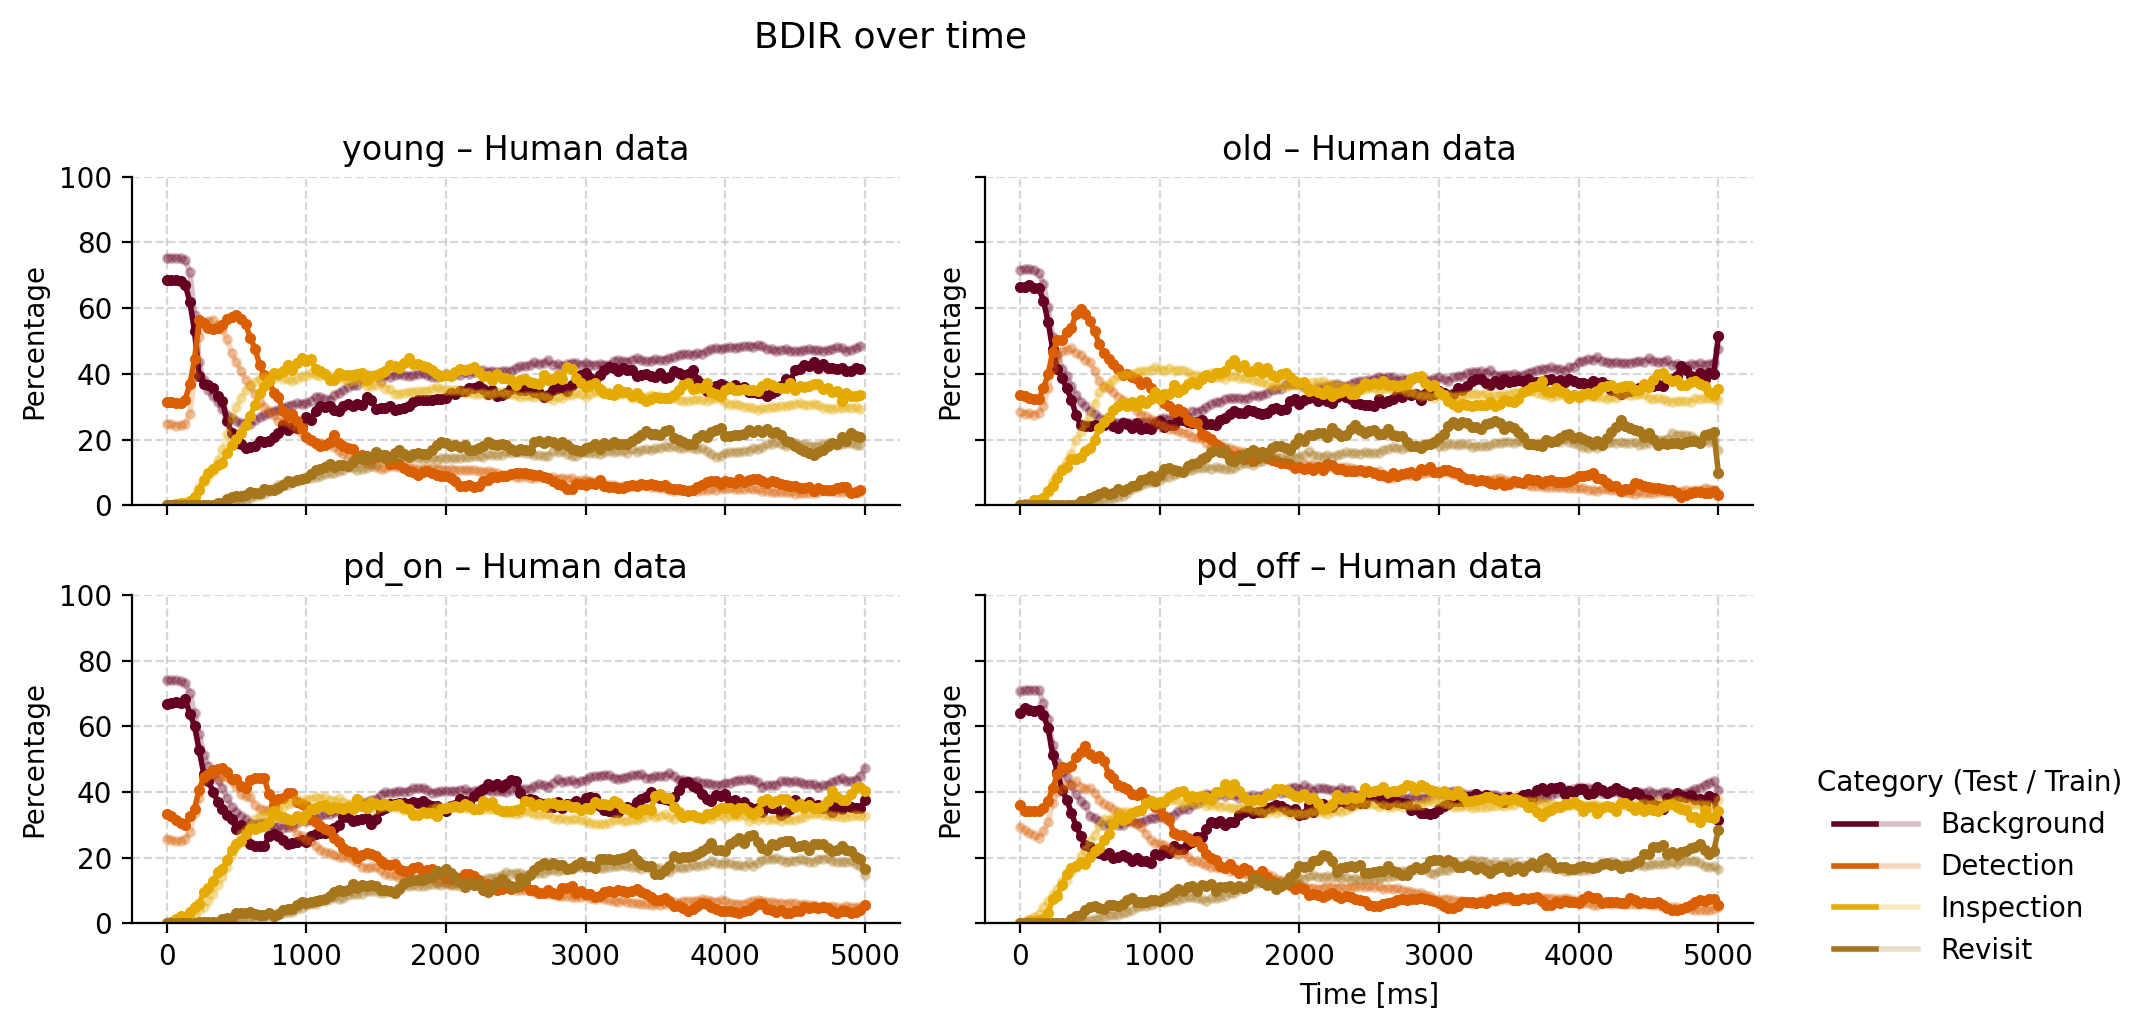


INTERSECTION SUMMARY

young - Human data

TRAIN-TRAIN INTERSECTIONS:
  1. Background ∩ Detection: Time = 223.8 ms, Percentage = 47.68%
  2. Background ∩ Detection: Time = 742.1 ms, Percentage = 28.26%
  3. Background ∩ Inspection: Time = 1387.9 ms, Percentage = 37.76%
  4. Detection ∩ Inspection: Time = 596.8 ms, Percentage = 36.49%
  5. Detection ∩ Revisit: Time = 1475.6 ms, Percentage = 12.19%

TEST-TEST INTERSECTIONS:
  1. Background ∩ Detection: Time = 211.2 ms, Percentage = 48.44%
  2. Background ∩ Detection: Time = 962.5 ms, Percentage = 23.74%
  3. Background ∩ Inspection: Time = 492.5 ms, Percentage = 19.71%
  4. Background ∩ Inspection: Time = 2496.3 ms, Percentage = 36.85%
  5. Background ∩ Inspection: Time = 2503.4 ms, Percentage = 36.84%
  6. Background ∩ Inspection: Time = 2940.6 ms, Percentage = 38.41%
  7. Background ∩ Inspection: Time = 3845.4 ms, Percentage = 36.18%
  8. Background ∩ Inspection: Time = 3888.0 ms, Percentage = 35.51%
  9. Background ∩ Inspection: Time 

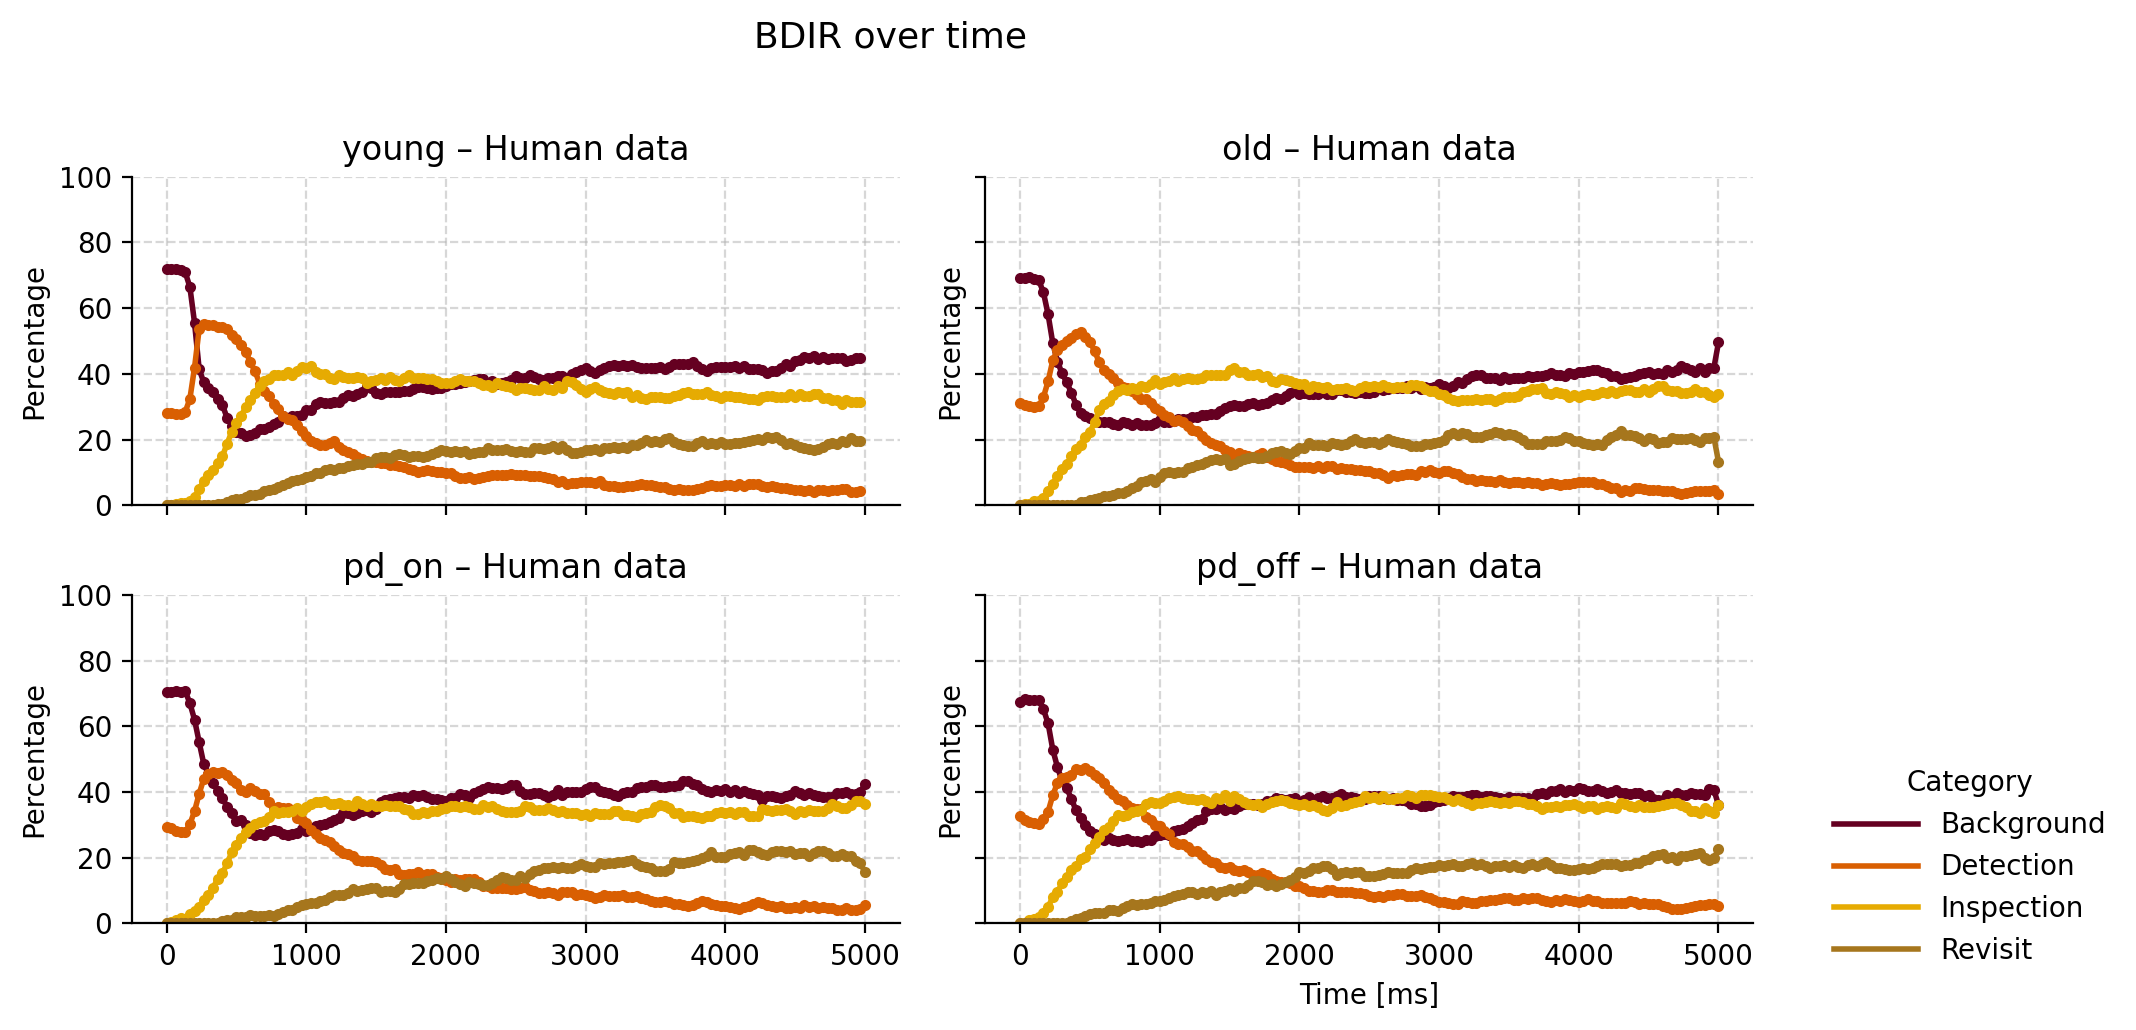


INTERSECTION SUMMARY

young - Human data

INTERSECTIONS:
  1. Background ∩ Detection: Time = 217.5 ms, Percentage = 48.08%
  2. Background ∩ Detection: Time = 841.2 ms, Percentage = 26.93%
  3. Background ∩ Inspection: Time = 480.5 ms, Percentage = 23.44%
  4. Background ∩ Inspection: Time = 2180.9 ms, Percentage = 37.95%
  5. Background ∩ Inspection: Time = 2362.1 ms, Percentage = 37.00%
  6. Background ∩ Inspection: Time = 2379.0 ms, Percentage = 37.00%
  7. Detection ∩ Inspection: Time = 673.7 ms, Percentage = 36.57%
  8. Detection ∩ Revisit: Time = 1466.7 ms, Percentage = 13.30%

MAXIMUM VALUES:
  Background: Max = 71.91% at Time = 66.7 ms
  Detection: Max = 55.15% at Time = 266.7 ms
  Inspection: Max = 42.38% at Time = 1033.3 ms
  Revisit: Max = 20.84% at Time = 4300.0 ms

old - Human data

INTERSECTIONS:
  1. Background ∩ Detection: Time = 253.3 ms, Percentage = 46.00%
  2. Background ∩ Detection: Time = 1117.3 ms, Percentage = 25.84%
  3. Background ∩ Inspection: Time = 538.4 m

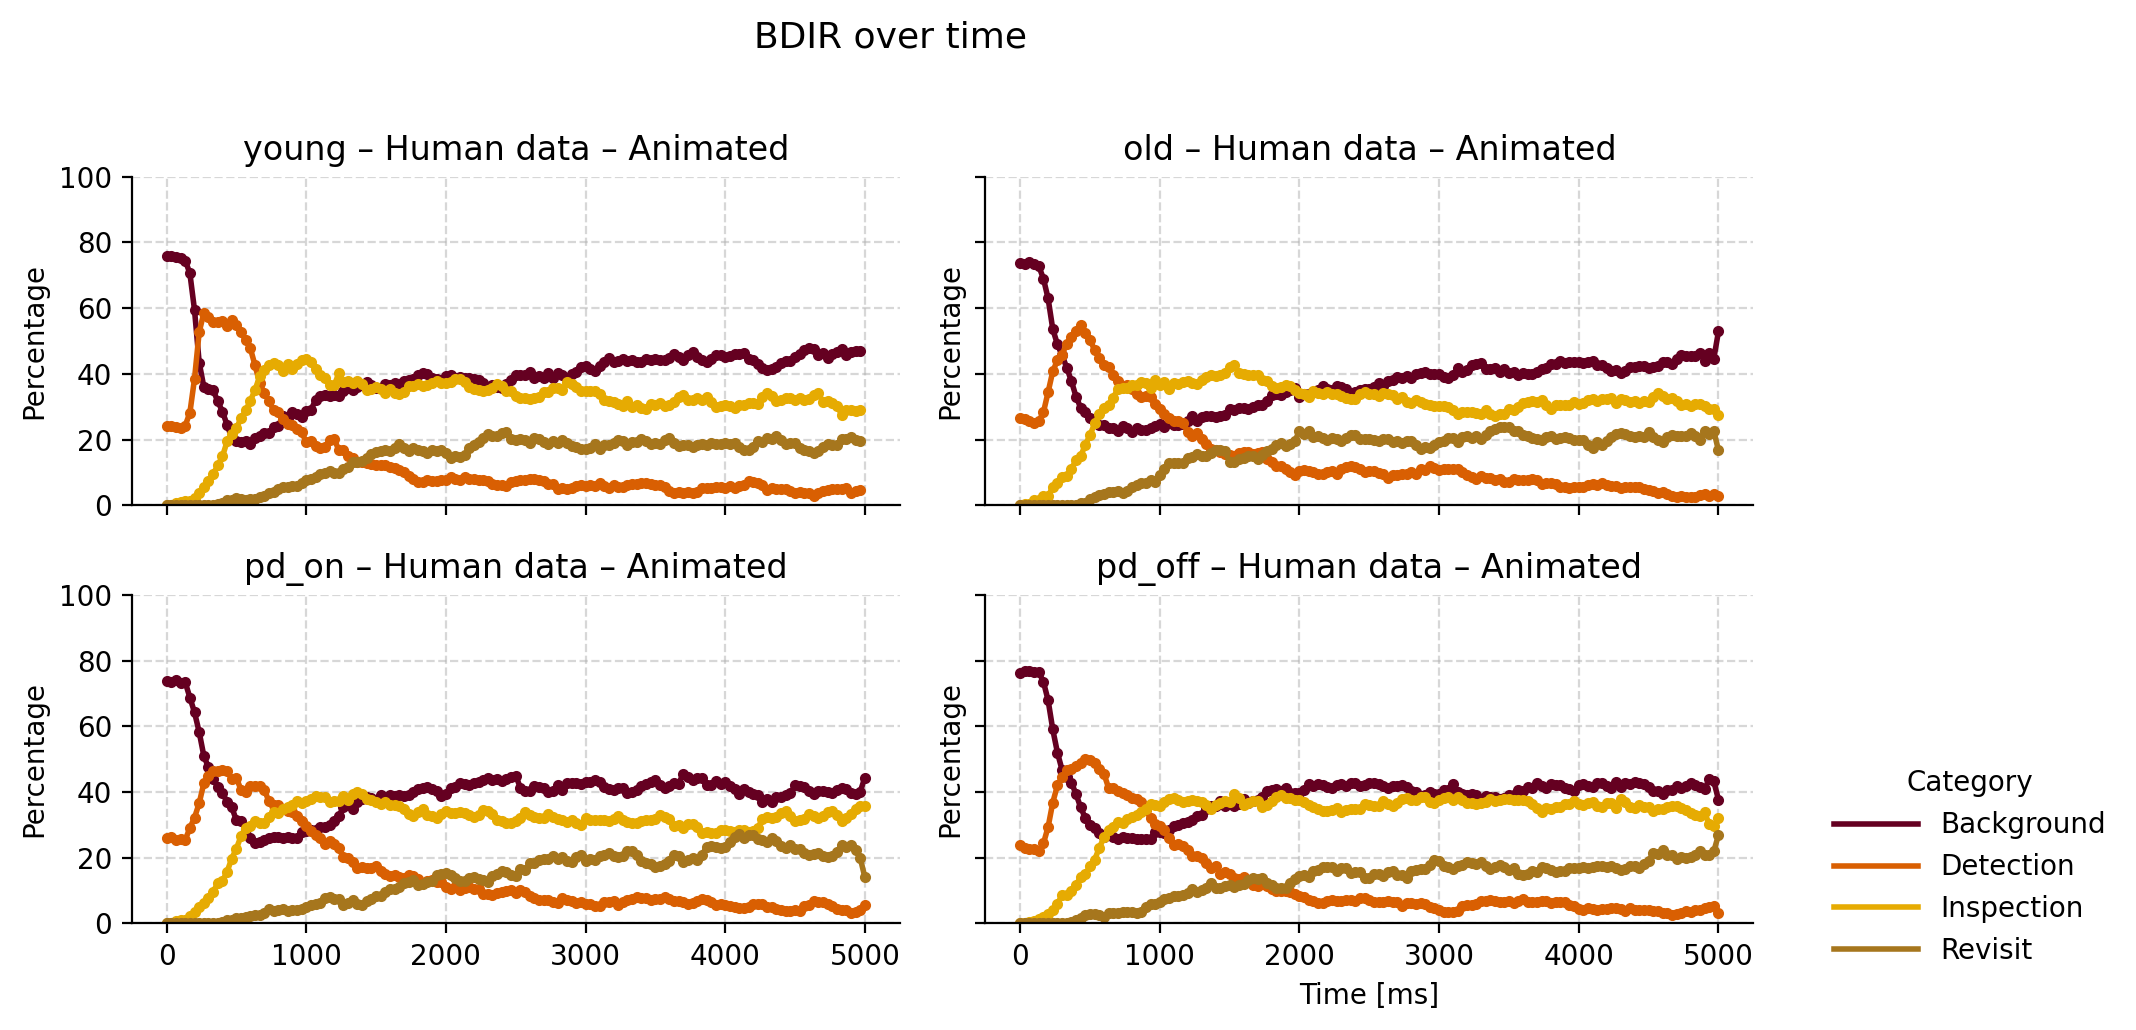


INTERSECTION SUMMARY

young - Human data

INTERSECTIONS:
  1. Background ∩ Detection: Time = 223.1 ms, Percentage = 48.34%
  2. Background ∩ Detection: Time = 827.2 ms, Percentage = 26.63%
  3. Background ∩ Inspection: Time = 460.8 ms, Percentage = 21.19%
  4. Background ∩ Inspection: Time = 1405.3 ms, Percentage = 36.66%
  5. Background ∩ Inspection: Time = 1499.7 ms, Percentage = 35.83%
  6. Background ∩ Inspection: Time = 1500.8 ms, Percentage = 35.82%
  7. Background ∩ Inspection: Time = 2350.1 ms, Percentage = 36.29%
  8. Background ∩ Inspection: Time = 2408.3 ms, Percentage = 35.91%
  9. Detection ∩ Inspection: Time = 659.5 ms, Percentage = 38.36%
  10. Detection ∩ Revisit: Time = 1362.6 ms, Percentage = 13.21%

MAXIMUM VALUES:
  Background: Max = 75.83% at Time = 33.3 ms
  Detection: Max = 58.50% at Time = 266.7 ms
  Inspection: Max = 44.55% at Time = 1000.0 ms
  Revisit: Max = 22.18% at Time = 2433.3 ms

old - Human data

INTERSECTIONS:
  1. Background ∩ Detection: Time = 298.

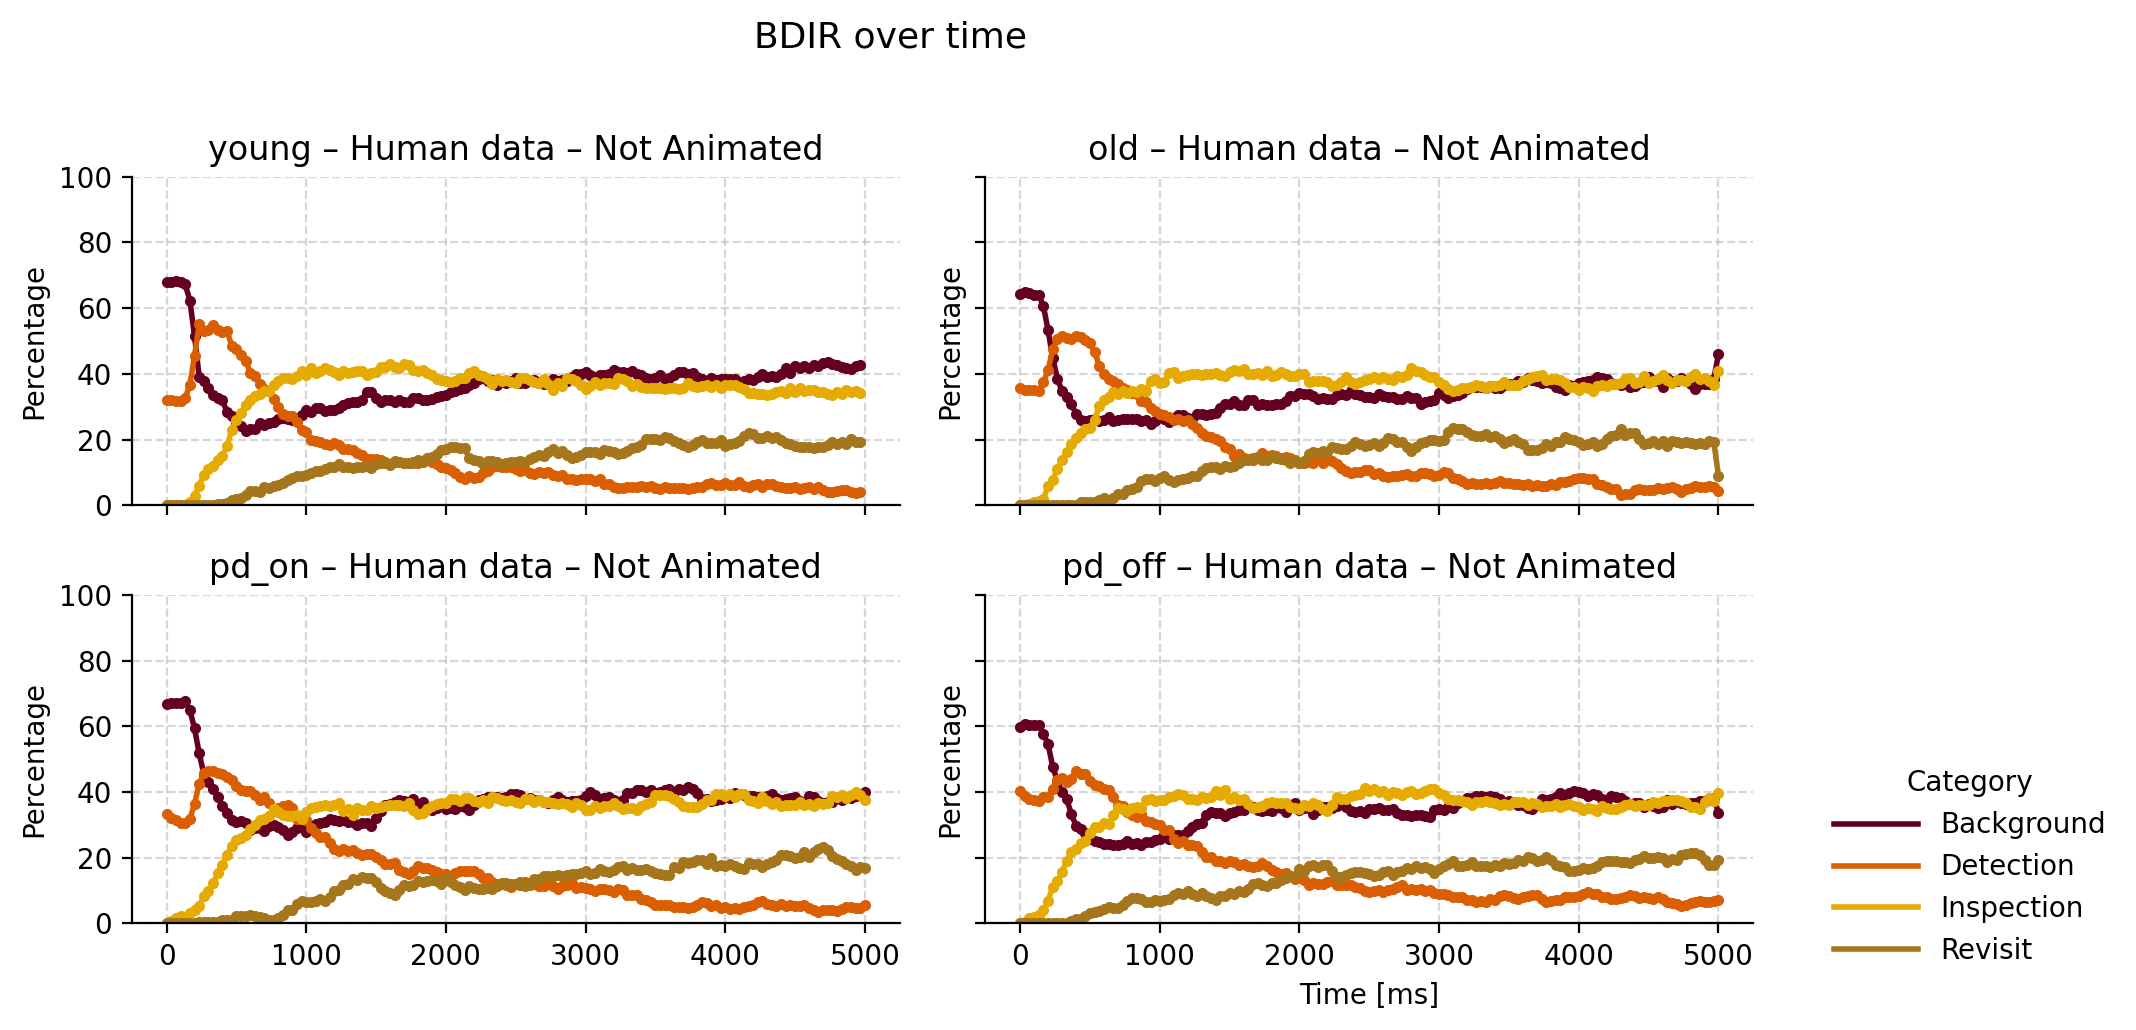


INTERSECTION SUMMARY

young - Human data

INTERSECTIONS:
  1. Background ∩ Detection: Time = 209.3 ms, Percentage = 48.12%
  2. Background ∩ Detection: Time = 916.8 ms, Percentage = 26.25%
  3. Background ∩ Inspection: Time = 491.5 ms, Percentage = 25.24%
  4. Background ∩ Inspection: Time = 2309.2 ms, Percentage = 37.88%
  5. Background ∩ Inspection: Time = 2348.0 ms, Percentage = 37.50%
  6. Background ∩ Inspection: Time = 2398.9 ms, Percentage = 37.89%
  7. Background ∩ Inspection: Time = 2402.1 ms, Percentage = 37.89%
  8. Background ∩ Inspection: Time = 2462.4 ms, Percentage = 37.65%
  9. Background ∩ Inspection: Time = 2517.7 ms, Percentage = 37.90%
  10. Background ∩ Inspection: Time = 2606.7 ms, Percentage = 38.06%
  11. Background ∩ Inspection: Time = 2665.4 ms, Percentage = 37.33%
  12. Background ∩ Inspection: Time = 2732.3 ms, Percentage = 36.87%
  13. Background ∩ Inspection: Time = 2855.7 ms, Percentage = 37.98%
  14. Background ∩ Inspection: Time = 2886.4 ms, Percentage

In [22]:
#  Plot with separate train/test data (all data)
fig, summary = plot_BDIR_over_time(VidCom, dircl, split_train_test=True)
plt.show()
print_intersection_summary(summary, split_train_test=True)

# Plot with combined train/test data (all data)
fig, summary = plot_BDIR_over_time(VidCom, dircl, split_train_test=False)
plt.show()
print_intersection_summary(summary, split_train_test=False)

# Plot with combined data, only animated
fig, summary = plot_BDIR_over_time(VidCom, dircl, split_train_test=False, animate=True)
plt.show()
print_intersection_summary(summary, split_train_test=False)


# Plot with combined data, only non-animated
fig, summary = plot_BDIR_over_time(VidCom, dircl, split_train_test=False, animate=False)
plt.show()
print_intersection_summary(summary, split_train_test=False)



------------------------